In [1]:
import os
import sys
import glob
import json
import h5py
import warnings
import numpy as np
import pandas as pd
from pathlib import Path
from datetime import datetime

from vip_slap2_analysis.io.session_registry import VIPSessionRegistry
from vip_slap2_analysis.utils.utils import save_figure

import matplotlib.pyplot as plt
from IPython.display import display, HTML

display(HTML("<style>.container { width:100% !important; }</style>"))
warnings.filterwarnings("default")

In [2]:
%matplotlib inline

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
today_str = datetime.today().strftime('%Y-%m-%d')

BASE_PATH = Path(r'\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics')
SAVE_PATH = Path(r'C:\Users\andrew.shelton\Dropbox\allen institute\Documents\Presentations\OPhys\Lab_Meetings\2026-07-28_OPhys_LabMeetingV\figures\voltage_plots')

TARGET_MICE = [
    826031,
    826032
]

PARADIGMS = ["change_detection_passive"]
EXCLUDE_SESSION_TYPES = ["expression_check", "volume_imaging"]

# Voltage extraction writes files like:
#   voltage_session_traces_dff_robust_f0_trial.h5
# This variant controls the filename suffix. The plotted dataset is SIGNAL below.
TRACE_VARIANT = "dff_robust_f0_trial"
SIGNAL = "dff"      # one of: "raw_f", "f0", "dff"

# Optional direct override. Leave as None to resolve from asset.derived_dir / "voltage".
SESSION_TRACE_H5 = None

In [5]:
registry = VIPSessionRegistry.from_basepath(BASE_PATH)

process_df = registry.sessions(
    subject_ids=TARGET_MICE,
    exclude_session_types=EXCLUDE_SESSION_TYPES,
    paradigms=PARADIGMS,
)

assets = [registry.resolve_assets(row) for _, row in process_df.iterrows()]

print(f"Found {len(assets)} candidate sessions.")
display(process_df)

Found 19 candidate sessions.


,session_id,subject_id,session_#,session_date,indicator1,indicator2,dmd1_depth,dmd2_depth,paradigm,session_type,...,instrument_id,camera_type,has raster ROI?,has integration roi?,behavior_rig,quality,flags,session_dir,purpose,notes
0,826031_2026-01-30_15-04-02,826031,2,2026-01-30,ASAP7y,NaN,50,250,change_detection_passive,familiar,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
1,826031_2026-02-01_11-01-50,826031,3,2026-02-01,ASAP7y,NaN,50,250,change_detection_passive,familiar,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
2,826031_2026-02-02_10-23-53,826031,4,2026-02-02,ASAP7y,NaN,50,250,change_detection_passive,familiar,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
3,826031_2026-02-03_14-21-45,826031,5,2026-02-03,ASAP7y,NaN,50,250,change_detection_passive,familiar,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
4,826031_2026-02-04_12-15-34,826031,6,2026-02-04,ASAP7y,NaN,50,250,change_detection_passive,familiar,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
5,826031_2026-02-05_09-28-56,826031,7,2026-02-05,ASAP7y,NaN,50,250,change_detection_passive,familiar,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
6,826031_2026-02-06_10-21-20,826031,8,2026-02-06,ASAP7y,NaN,50,250,change_detection_passive,familiar,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
7,826031_2026-02-10_10-48-51,826031,9,2026-02-10,ASAP7y,NaN,50,250,change_detection_passive,novel,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
8,826031_2026-02-11_12-42-21,826031,10,2026-02-11,ASAP7y,NaN,50,250,change_detection_passive,novel+,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
9,826031_2026-02-12_07-43-37,826031,11,2026-02-12,ASAP7y,NaN,50,250,change_detection_passive,novel+,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN


#### Inspect one session's metadata

In [61]:
# %%
SESSION_INDEX = -2  # change this to inspect a different session

asset = assets[SESSION_INDEX]
row = process_df.iloc[SESSION_INDEX]

print("Selected session index:", SESSION_INDEX)
display(row)

def _maybe_get(obj, name, default=None):
    """Safely get attr or dict key from an asset-like object."""
    if hasattr(obj, name):
        return getattr(obj, name)
    if isinstance(obj, dict) and name in obj:
        return obj[name]
    return default

def resolve_voltage_h5(asset, trace_variant=TRACE_VARIANT, session_trace_h5=SESSION_TRACE_H5):
    """
    Resolve the session-long voltage trace H5 path.
    
    Expected filename:
        voltage_session_traces_{TRACE_VARIANT}.h5
        
    Uses SESSION_TRACE_H5 if provided; otherwise tries asset.derived_dir / voltage.
    """
    if session_trace_h5 is not None:
        path = Path(session_trace_h5)
        if not path.exists():
            raise FileNotFoundError(path)
        return path

    derived_dir = _maybe_get(asset, "derived_dir", None)
    if derived_dir is None:
        raise ValueError("Could not find asset.derived_dir. Set SESSION_TRACE_H5 manually.")

    derived_dir = Path(derived_dir)

    candidates = [
        derived_dir / "voltage" / f"voltage_session_traces_{trace_variant}.h5",
        derived_dir / f"voltage_session_traces_{trace_variant}.h5",
    ]

    for path in candidates:
        if path.exists():
            return path

    print("Tried:")
    for path in candidates:
        print("  ", path)

    raise FileNotFoundError("Could not resolve voltage session trace H5.")

trace_h5 = resolve_voltage_h5(asset)
print("Trace H5:", trace_h5)

Selected session index: -2


session_id                                     826032_2026-02-10_13-02-11
subject_id                                                         826032
session_#                                                               9
session_date                                          2026-02-10 00:00:00
indicator1                                                         ASAP7y
indicator2                                                            NaN
dmd1_depth                                                             50
dmd2_depth                                                            250
paradigm                                         change_detection_passive
session_type                                                        novel
stimulus                                                          image_B
experimentor                                               Andrew Shelton
instrument_name                                              slap2_albert
instrument_id                         

Trace H5: \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\ASAP7\826032\826032_2026-02-10_13-02-11\analysis\derived\voltage\voltage_session_traces_dff_robust_f0_trial.h5


In [62]:
# %%
def inspect_voltage_h5(trace_h5, signal=SIGNAL, n_fs_samples=200_000):
    """
    Inspect a voltage session H5 without loading full arrays.
    """
    rows = []

    with h5py.File(trace_h5, "r") as h5:
        dmd_keys = sorted([k for k in h5.keys() if k.upper().startswith("DMD")])

        print("DMD groups:", dmd_keys)
        print()

        for dmd in dmd_keys:
            g = h5[dmd]

            if signal not in g:
                print(f"Skipping {dmd}: signal '{signal}' not found. Available keys: {list(g.keys())}")
                continue

            y_ds = g[signal]
            t_ds = g["timebase_sec"]

            n_rois, n_samples = y_ds.shape

            # Estimate sampling rate from a subset of the timebase.
            n_check = min(n_fs_samples, n_samples)
            t_check = t_ds[:n_check]
            dt = np.nanmedian(np.diff(t_check))
            fs = 1.0 / dt

            t0 = float(t_ds[0])
            t1 = float(t_ds[n_samples - 1])
            duration_sec = t1 - t0

            valid_rois = None
            if "valid_rois_mask" in g:
                valid_rois = g["valid_rois_mask"][:].astype(bool)
                n_valid = int(np.sum(valid_rois))
            else:
                n_valid = np.nan

            approx_gb = y_ds.size * y_ds.dtype.itemsize / 1e9

            rows.append({
                "dmd": dmd,
                "signal": signal,
                "n_rois": n_rois,
                "n_valid_rois": n_valid,
                "n_samples": n_samples,
                "duration_min": duration_sec / 60,
                "fs_hz_est": fs,
                "dt_ms_est": 1000 * dt,
                "dataset_dtype": str(y_ds.dtype),
                "dataset_size_GB": approx_gb,
            })

    return pd.DataFrame(rows)

session_info = inspect_voltage_h5(trace_h5, signal=SIGNAL)
display(session_info)

DMD groups: ['DMD1', 'DMD2']



,dmd,signal,n_rois,n_valid_rois,n_samples,duration_min,fs_hz_est,dt_ms_est,dataset_dtype,dataset_size_GB
0,DMD1,dff,21,16,18705443,29.948462,10686.718366,0.093574,float32,1.571257
1,DMD2,dff,17,13,18705443,29.948462,10686.718366,0.093574,float32,1.271970


#### Load data, low frequency analysis

## Low-frequency whole-session loading

### This section loads one voltage session into a downsampled representation suitable for
### low/mid-frequency analyses:

#### - ROI-wise PSD
#### - DMD-average PSD
#### - DMD1/DMD2 coherence
#### - common-mode vs difference-mode spectra
#### - running/task residual spectra

### The loader:

#### 1. reads each ROI one at a time from the H5 file,
#### 2. detects large timebase gaps,
#### 3. downsamples each contiguous segment separately to avoid filtering across gaps,
#### 4. keeps valid ROI identities,
#### 5. optionally caches the result as an `.npz` file next to the H5.

In [63]:
# %%
from scipy import signal as scipy_signal

try:
    from tqdm.auto import tqdm
except Exception:
    tqdm = None


# ---------------------------------------------------------------------
# Low-frequency loading parameters
# ---------------------------------------------------------------------

LOWFREQ_TARGET_FS_HZ = 500.0
# 500 Hz is still a "low/mid-frequency" working copy relative to ~10.8 kHz raw sampling.
# It preserves content up to ~200 Hz reasonably well after anti-aliasing, but spike-like
# event analysis should still be done later on high-rate chunks.

LOWFREQ_VALID_ROIS_ONLY = True

# Set this to e.g. 300 for a quick smoke test.
# Leave as None to load the full session.
LOWFREQ_MAX_SECONDS = None

# Detect discontinuities in timebase_sec.
# A boundary is flagged when dt > TIMEBASE_GAP_FACTOR * median_dt.
TIMEBASE_GAP_FACTOR = 5.0

# Very short segments are poor for spectral analyses and can produce filter edge artifacts.
# They are dropped during low-frequency loading.
LOWFREQ_MIN_SEGMENT_SEC = 2.0

# Cache the downsampled data so that re-running the notebook is fast.
LOWFREQ_USE_CACHE = True
LOWFREQ_FORCE_RELOAD = False

In [64]:
# %%
def _decode_roi_ids(roi_ids):
    """Decode ROI ids from HDF5 bytes/strings into a clean numpy string array."""
    out = []
    for x in roi_ids:
        if isinstance(x, bytes):
            out.append(x.decode("utf-8"))
        else:
            out.append(str(x))
    return np.asarray(out, dtype=str)


def _get_dmd_keys(h5):
    """Return sorted DMD group names."""
    return sorted([k for k in h5.keys() if k.upper().startswith("DMD")])


def _estimate_fs_from_timebase(t, n_check=200_000):
    """Estimate sampling rate from the start of a timebase vector."""
    n = min(int(n_check), len(t))
    tt = np.asarray(t[:n], dtype=np.float64)
    dt = np.diff(tt)
    dt = dt[np.isfinite(dt)]
    if dt.size == 0:
        raise ValueError("Could not estimate sampling rate from timebase.")
    median_dt = float(np.nanmedian(dt))
    fs = 1.0 / median_dt
    return fs, median_dt


def _infer_trace_layout(y_ds, t_ds):
    """
    Infer whether the trace dataset is ROI x time or time x ROI.

    Returns
    -------
    layout : str
        Either "roi_time" or "time_roi".
    n_rois : int
    n_time : int
    """
    n_time = int(t_ds.shape[0])

    if y_ds.shape[-1] == n_time:
        return "roi_time", int(y_ds.shape[0]), n_time

    if y_ds.shape[0] == n_time:
        return "time_roi", int(y_ds.shape[1]), n_time

    raise ValueError(
        f"Could not infer trace layout. Trace shape={y_ds.shape}, "
        f"timebase length={n_time}"
    )


def _read_roi_trace(y_ds, roi_index, layout, n_time_use=None):
    """Read one ROI trace from an HDF5 dataset."""
    if n_time_use is None:
        n_time_use = y_ds.shape[-1] if layout == "roi_time" else y_ds.shape[0]

    if layout == "roi_time":
        y = np.asarray(y_ds[roi_index, :n_time_use], dtype=np.float32)
    elif layout == "time_roi":
        y = np.asarray(y_ds[:n_time_use, roi_index], dtype=np.float32)
    else:
        raise ValueError(f"Unknown layout: {layout}")

    return y


def _interp_nans_1d(y):
    """Interpolate NaNs/infs in a 1D trace."""
    y = np.asarray(y, dtype=np.float32)
    finite = np.isfinite(y)

    if finite.all():
        return y

    if finite.sum() < 2:
        return np.zeros_like(y, dtype=np.float32)

    x = np.arange(y.size)
    y = y.copy()
    y[~finite] = np.interp(x[~finite], x[finite], y[finite]).astype(np.float32)
    return y


def _find_timebase_segments(t, fs_hz, gap_factor=5.0, min_segment_sec=2.0):
    """
    Find contiguous sample segments from a timebase.

    Boundaries are detected when dt is much larger than the nominal sampling interval.
    """
    t = np.asarray(t, dtype=np.float64)
    dt = np.diff(t)

    nominal_dt = 1.0 / float(fs_hz)
    gap_threshold = gap_factor * nominal_dt

    gap_locs = np.where(dt > gap_threshold)[0]

    starts = np.r_[0, gap_locs + 1]
    stops = np.r_[gap_locs + 1, len(t)]

    min_samples = max(2, int(np.ceil(min_segment_sec * fs_hz)))

    keep = (stops - starts) >= min_samples
    starts = starts[keep]
    stops = stops[keep]

    segments = np.column_stack([starts, stops]).astype(np.int64)

    audit = {
        "nominal_dt_sec": nominal_dt,
        "gap_threshold_sec": gap_threshold,
        "n_detected_gaps": int(len(gap_locs)),
        "n_kept_segments": int(len(segments)),
        "min_segment_sec": float(min_segment_sec),
        "max_dt_sec": float(np.nanmax(dt)) if dt.size else np.nan,
        "median_dt_sec": float(np.nanmedian(dt)) if dt.size else np.nan,
    }

    return segments, audit


def _resample_poly_1d(y, down):
    """
    Anti-aliased decimation using scipy.signal.resample_poly.

    The try/except keeps this compatible with older scipy versions that may not
    support padtype.
    """
    y = _interp_nans_1d(y)

    if down <= 1:
        return y.astype(np.float32, copy=False)

    try:
        y_low = scipy_signal.resample_poly(
            y,
            up=1,
            down=down,
            window=("kaiser", 8.6),
            padtype="line",
        )
    except TypeError:
        y_low = scipy_signal.resample_poly(
            y,
            up=1,
            down=down,
            window=("kaiser", 8.6),
        )

    return y_low.astype(np.float32, copy=False)


def _downsample_trace_by_segments(y, segments_sample, down):
    """
    Downsample one full-rate ROI trace segment-by-segment, then concatenate.
    """
    parts = []

    for start, stop in segments_sample:
        y_seg = y[int(start):int(stop)]
        y_low = _resample_poly_1d(y_seg, down=down)
        parts.append(y_low)

    if len(parts) == 0:
        return np.asarray([], dtype=np.float32)

    return np.concatenate(parts).astype(np.float32, copy=False)


def _make_lowfreq_timebase(t, segments_sample, fs_low_hz, down):
    """
    Construct a low-frequency timebase and low-frequency segment table.

    Returns
    -------
    time_low : ndarray
        Concatenated low-frequency sample times in original session seconds.
    segments_low : ndarray
        Columns:
            low_start_index, low_stop_index, start_sec, stop_sec
    """
    time_parts = []
    seg_rows = []
    cursor = 0

    for start, stop in segments_sample:
        start = int(start)
        stop = int(stop)

        n_in = stop - start
        n_out = int(np.ceil(n_in / down))

        t0 = float(t[start])
        tt = t0 + np.arange(n_out, dtype=np.float64) / fs_low_hz

        time_parts.append(tt)

        seg_rows.append([
            cursor,
            cursor + n_out,
            float(t[start]),
            float(t[stop - 1]),
        ])

        cursor += n_out

    if len(time_parts) == 0:
        time_low = np.asarray([], dtype=np.float64)
        segments_low = np.empty((0, 4), dtype=np.float64)
    else:
        time_low = np.concatenate(time_parts)
        segments_low = np.asarray(seg_rows, dtype=np.float64)

    return time_low, segments_low

In [65]:
# %%
def _lowfreq_cache_path(trace_h5, signal, target_fs_hz, valid_rois_only, max_seconds):
    max_tag = "full" if max_seconds is None else f"first{int(max_seconds)}s"
    valid_tag = "validrois" if valid_rois_only else "allrois"
    fname = (
        f"{Path(trace_h5).stem}"
        f"__{signal}"
        f"__lowfreq_fs{target_fs_hz:g}"
        f"__{valid_tag}"
        f"__{max_tag}.npz"
    )
    return Path(trace_h5).with_name(fname)


def _save_lowfreq_cache(lf, cache_path):
    """Save low-frequency session dict to NPZ."""
    save_dict = {
        "trace_h5": str(lf["trace_h5"]),
        "signal": str(lf["signal"]),
        "target_fs_hz": float(lf["target_fs_hz"]),
        "dmd_keys": np.asarray(list(lf["dmd"].keys()), dtype=str),
    }

    for dmd, d in lf["dmd"].items():
        save_dict[f"{dmd}_X"] = d["X"]
        save_dict[f"{dmd}_time_sec"] = d["time_sec"]
        save_dict[f"{dmd}_segments_sample"] = d["segments_sample"]
        save_dict[f"{dmd}_segments_low"] = d["segments_low"]
        save_dict[f"{dmd}_roi_ids"] = np.asarray(d["roi_ids"], dtype=str)
        save_dict[f"{dmd}_source_roi_indices"] = np.asarray(d["source_roi_indices"], dtype=np.int64)
        save_dict[f"{dmd}_fs_source_hz"] = float(d["fs_source_hz"])
        save_dict[f"{dmd}_fs_low_hz"] = float(d["fs_low_hz"])
        save_dict[f"{dmd}_decimation"] = int(d["decimation"])
        save_dict[f"{dmd}_timebase_audit_keys"] = np.asarray(list(d["timebase_audit"].keys()), dtype=str)
        save_dict[f"{dmd}_timebase_audit_values"] = np.asarray(list(d["timebase_audit"].values()), dtype=float)

    np.savez(cache_path, **save_dict)


def _load_lowfreq_cache(cache_path):
    """Load low-frequency session dict from NPZ."""
    with np.load(cache_path, allow_pickle=False) as z:
        dmd_keys = [str(x) for x in z["dmd_keys"]]

        lf = {
            "trace_h5": Path(str(z["trace_h5"].item())),
            "signal": str(z["signal"].item()),
            "target_fs_hz": float(z["target_fs_hz"]),
            "dmd": {},
            "cache_path": Path(cache_path),
        }

        for dmd in dmd_keys:
            audit_keys = [str(x) for x in z[f"{dmd}_timebase_audit_keys"]]
            audit_vals = [float(x) for x in z[f"{dmd}_timebase_audit_values"]]
            audit = dict(zip(audit_keys, audit_vals))

            lf["dmd"][dmd] = {
                "X": z[f"{dmd}_X"].astype(np.float32, copy=False),
                "time_sec": z[f"{dmd}_time_sec"].astype(np.float64, copy=False),
                "segments_sample": z[f"{dmd}_segments_sample"].astype(np.int64, copy=False),
                "segments_low": z[f"{dmd}_segments_low"].astype(np.float64, copy=False),
                "roi_ids": z[f"{dmd}_roi_ids"].astype(str),
                "source_roi_indices": z[f"{dmd}_source_roi_indices"].astype(np.int64, copy=False),
                "fs_source_hz": float(z[f"{dmd}_fs_source_hz"]),
                "fs_low_hz": float(z[f"{dmd}_fs_low_hz"]),
                "decimation": int(z[f"{dmd}_decimation"]),
                "timebase_audit": audit,
            }

    return lf


def load_lowfreq_voltage_session(
    trace_h5,
    signal="dff",
    target_fs_hz=500.0,
    valid_rois_only=True,
    max_seconds=None,
    gap_factor=5.0,
    min_segment_sec=2.0,
    use_cache=True,
    force_reload=False,
):
    """
    Load a session-long voltage H5 into a low-frequency, ROI x time representation.

    Output
    ------
    lf : dict
        Main fields:
            lf["dmd"][DMD]["X"]                # n_rois x n_low_samples
            lf["dmd"][DMD]["time_sec"]         # n_low_samples
            lf["dmd"][DMD]["roi_ids"]          # loaded ROI ids
            lf["dmd"][DMD]["segments_low"]     # low-frequency contiguous segments
            lf["dmd"][DMD]["fs_low_hz"]        # actual low-frequency sampling rate
    """
    trace_h5 = Path(trace_h5)

    cache_path = _lowfreq_cache_path(
        trace_h5=trace_h5,
        signal=signal,
        target_fs_hz=target_fs_hz,
        valid_rois_only=valid_rois_only,
        max_seconds=max_seconds,
    )

    if use_cache and cache_path.exists() and not force_reload:
        print(f"Loading cached low-frequency session:\n  {cache_path}")
        return _load_lowfreq_cache(cache_path)

    lf = {
        "trace_h5": trace_h5,
        "signal": signal,
        "target_fs_hz": float(target_fs_hz),
        "dmd": {},
        "cache_path": cache_path,
    }

    with h5py.File(trace_h5, "r") as h5:
        dmd_keys = _get_dmd_keys(h5)
        print("DMD groups:", dmd_keys)

        for dmd in dmd_keys:
            print()
            print("=" * 80)
            print(f"Loading {dmd}")

            g = h5[dmd]

            if signal not in g:
                print(f"Skipping {dmd}: no dataset named {signal}. Available keys: {list(g.keys())}")
                continue

            y_ds = g[signal]
            t_ds = g["timebase_sec"]

            layout, n_rois_total, n_time_total = _infer_trace_layout(y_ds, t_ds)

            # Load timebase. This is intentionally done once per DMD so that we can
            # detect discontinuities before filtering.
            if max_seconds is None:
                n_time_use = n_time_total
                t = np.asarray(t_ds[:], dtype=np.float64)
            else:
                # Initial approximate conversion from seconds to samples.
                fs_tmp, _ = _estimate_fs_from_timebase(t_ds)
                n_time_use = min(n_time_total, int(np.ceil(max_seconds * fs_tmp)))
                t = np.asarray(t_ds[:n_time_use], dtype=np.float64)

            fs_source_hz, median_dt = _estimate_fs_from_timebase(t)
            down = max(1, int(np.round(fs_source_hz / target_fs_hz)))
            fs_low_hz = fs_source_hz / down

            segments_sample, audit = _find_timebase_segments(
                t=t,
                fs_hz=fs_source_hz,
                gap_factor=gap_factor,
                min_segment_sec=min_segment_sec,
            )

            time_low, segments_low = _make_lowfreq_timebase(
                t=t,
                segments_sample=segments_sample,
                fs_low_hz=fs_low_hz,
                down=down,
            )

            if "roi_ids" in g:
                roi_ids_all = _decode_roi_ids(g["roi_ids"][:])
            else:
                roi_ids_all = np.asarray([f"{dmd}_roi{i:03d}" for i in range(n_rois_total)], dtype=str)

            if valid_rois_only and "valid_rois_mask" in g:
                valid_mask = np.asarray(g["valid_rois_mask"][:], dtype=bool)
                source_roi_indices = np.where(valid_mask)[0].astype(np.int64)
            else:
                source_roi_indices = np.arange(n_rois_total, dtype=np.int64)

            roi_ids = roi_ids_all[source_roi_indices]

            print(f"Trace layout: {layout}")
            print(f"Full-rate shape: {y_ds.shape}")
            print(f"Using {len(source_roi_indices)} / {n_rois_total} ROIs")
            print(f"Source fs: {fs_source_hz:.3f} Hz")
            print(f"Target fs: {target_fs_hz:.3f} Hz")
            print(f"Decimation factor: {down}")
            print(f"Actual low-frequency fs: {fs_low_hz:.3f} Hz")
            print(f"Detected timebase gaps: {audit['n_detected_gaps']}")
            print(f"Kept contiguous segments: {audit['n_kept_segments']}")
            print(f"Low-frequency samples: {len(time_low):,}")

            if len(time_low) == 0:
                raise RuntimeError(f"No low-frequency samples produced for {dmd}.")

            X = np.empty((len(source_roi_indices), len(time_low)), dtype=np.float32)

            iterator = enumerate(source_roi_indices)
            if tqdm is not None:
                iterator = tqdm(
                    iterator,
                    total=len(source_roi_indices),
                    desc=f"{dmd} ROIs",
                )

            for out_idx, source_roi_idx in iterator:
                y = _read_roi_trace(
                    y_ds=y_ds,
                    roi_index=int(source_roi_idx),
                    layout=layout,
                    n_time_use=n_time_use,
                )

                y_low = _downsample_trace_by_segments(
                    y=y,
                    segments_sample=segments_sample,
                    down=down,
                )

                # In rare cases, scipy's output length can differ by one sample because of
                # boundary handling. Trim/pad defensively.
                if y_low.size > len(time_low):
                    y_low = y_low[:len(time_low)]
                elif y_low.size < len(time_low):
                    pad = len(time_low) - y_low.size
                    y_low = np.pad(y_low, (0, pad), mode="edge")

                X[out_idx, :] = y_low

            lf["dmd"][dmd] = {
                "X": X,
                "time_sec": time_low,
                "segments_sample": segments_sample,
                "segments_low": segments_low,
                "roi_ids": roi_ids,
                "source_roi_indices": source_roi_indices,
                "fs_source_hz": float(fs_source_hz),
                "fs_low_hz": float(fs_low_hz),
                "decimation": int(down),
                "timebase_audit": audit,
            }

    if use_cache:
        print()
        print(f"Saving cache:\n  {cache_path}")
        _save_lowfreq_cache(lf, cache_path)

    return lf

In [66]:
# %%
# Resolve trace_h5 if this notebook section is being run independently.
if "trace_h5" not in globals():
    SESSION_INDEX = 0
    asset = assets[SESSION_INDEX]
    trace_h5 = resolve_voltage_h5(asset)

print("Loading low-frequency data from:")
print(trace_h5)

lf = load_lowfreq_voltage_session(
    trace_h5=trace_h5,
    signal=SIGNAL,
    target_fs_hz=LOWFREQ_TARGET_FS_HZ,
    valid_rois_only=LOWFREQ_VALID_ROIS_ONLY,
    max_seconds=LOWFREQ_MAX_SECONDS,
    gap_factor=TIMEBASE_GAP_FACTOR,
    min_segment_sec=LOWFREQ_MIN_SEGMENT_SEC,
    use_cache=LOWFREQ_USE_CACHE,
    force_reload=LOWFREQ_FORCE_RELOAD,
)

Loading low-frequency data from:
\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\ASAP7\826032\826032_2026-02-10_13-02-11\analysis\derived\voltage\voltage_session_traces_dff_robust_f0_trial.h5
DMD groups: ['DMD1', 'DMD2']

Loading DMD1
Trace layout: roi_time
Full-rate shape: (21, 18705443)
Using 16 / 21 ROIs
Source fs: 10686.718 Hz
Target fs: 500.000 Hz
Decimation factor: 21
Actual low-frequency fs: 508.891 Hz
Detected timebase gaps: 2
Kept contiguous segments: 3
Low-frequency samples: 890,737


DMD1 ROIs:   0%|          | 0/16 [00:00<?, ?it/s]


Loading DMD2
Trace layout: roi_time
Full-rate shape: (17, 18705443)
Using 13 / 17 ROIs
Source fs: 10686.718 Hz
Target fs: 500.000 Hz
Decimation factor: 21
Actual low-frequency fs: 508.891 Hz
Detected timebase gaps: 2
Kept contiguous segments: 3
Low-frequency samples: 890,737


DMD2 ROIs:   0%|          | 0/13 [00:00<?, ?it/s]


Saving cache:
  \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\ASAP7\826032\826032_2026-02-10_13-02-11\analysis\derived\voltage\voltage_session_traces_dff_robust_f0_trial__dff__lowfreq_fs500__validrois__full.npz


In [67]:
# %%
def summarize_lowfreq_loaded_session(lf):
    rows = []

    for dmd, d in lf["dmd"].items():
        X = d["X"]
        time_sec = d["time_sec"]
        seg = d["segments_low"]

        if len(time_sec) > 1:
            duration_recorded_sec = len(time_sec) / d["fs_low_hz"]
            elapsed_session_sec = float(np.nanmax(time_sec) - np.nanmin(time_sec))
        else:
            duration_recorded_sec = np.nan
            elapsed_session_sec = np.nan

        rows.append({
            "dmd": dmd,
            "n_rois": X.shape[0],
            "n_low_samples": X.shape[1],
            "fs_source_hz": d["fs_source_hz"],
            "fs_low_hz": d["fs_low_hz"],
            "decimation": d["decimation"],
            "n_segments": int(seg.shape[0]),
            "recorded_duration_min": duration_recorded_sec / 60,
            "elapsed_session_min": elapsed_session_sec / 60,
            "array_size_MB": X.nbytes / 1e6,
            "detected_timebase_gaps": int(d["timebase_audit"]["n_detected_gaps"]),
        })

    return pd.DataFrame(rows)


lowfreq_summary = summarize_lowfreq_loaded_session(lf)
display(lowfreq_summary)

for dmd, d in lf["dmd"].items():
    print()
    print(dmd)
    print("ROI ids:", list(d["roi_ids"]))
    print("Timebase audit:", d["timebase_audit"])

,dmd,n_rois,n_low_samples,fs_source_hz,fs_low_hz,decimation,n_segments,recorded_duration_min,elapsed_session_min,array_size_MB,detected_timebase_gaps
0,DMD1,16,890737,10686.718366,508.891351,21,3,29.172468,30.046153,57.007168,2
1,DMD2,13,890737,10686.718366,508.891351,21,3,29.172468,30.046153,46.318324,2



DMD1
ROI ids: ['DMD1_roi0000', 'DMD1_roi0003', 'DMD1_roi0004', 'DMD1_roi0005', 'DMD1_roi0006', 'DMD1_roi0008', 'DMD1_roi0009', 'DMD1_roi0010', 'DMD1_roi0012', 'DMD1_roi0013', 'DMD1_roi0014', 'DMD1_roi0015', 'DMD1_roi0016', 'DMD1_roi0017', 'DMD1_roi0019', 'DMD1_roi0020']
Timebase audit: {'nominal_dt_sec': 9.357409503962799e-05, 'gap_threshold_sec': 0.00046787047519813996, 'n_detected_gaps': 2, 'n_kept_segments': 3, 'min_segment_sec': 2.0, 'max_dt_sec': 43.536829573958585, 'median_dt_sec': 9.357409498989e-05}

DMD2
ROI ids: ['DMD2_roi0000', 'DMD2_roi0001', 'DMD2_roi0002', 'DMD2_roi0004', 'DMD2_roi0005', 'DMD2_roi0006', 'DMD2_roi0007', 'DMD2_roi0008', 'DMD2_roi0009', 'DMD2_roi0010', 'DMD2_roi0013', 'DMD2_roi0014', 'DMD2_roi0016']
Timebase audit: {'nominal_dt_sec': 9.357409503962799e-05, 'gap_threshold_sec': 0.00046787047519813996, 'n_detected_gaps': 2, 'n_kept_segments': 3, 'min_segment_sec': 2.0, 'max_dt_sec': 43.536829573958585, 'median_dt_sec': 9.357409498989e-05}


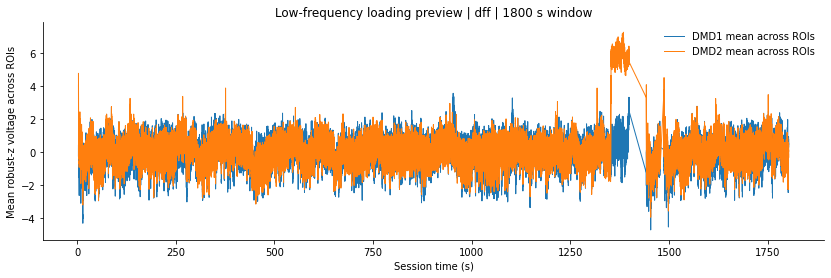

In [68]:
# %%
def robust_zscore_rows(X, eps=1e-8):
    """
    Robust z-score each ROI using median/MAD.

    For preview plotting only. Later analyses can choose explicit normalization.
    """
    X = np.asarray(X, dtype=np.float32)
    med = np.nanmedian(X, axis=1, keepdims=True)
    mad = np.nanmedian(np.abs(X - med), axis=1, keepdims=True)
    scale = 1.4826 * mad
    scale = np.maximum(scale, eps)
    return (X - med) / scale


def plot_lowfreq_loading_preview(lf, start_sec=None, duration_sec=300):
    """
    Quick sanity plot of loaded low-frequency population activity.

    Plots the robust-z-scored mean across ROIs on each DMD.
    """
    dmd_keys = list(lf["dmd"].keys())

    if start_sec is None:
        start_sec = min(float(lf["dmd"][dmd]["time_sec"][0]) for dmd in dmd_keys)

    stop_sec = start_sec + duration_sec

    fig, ax = plt.subplots(figsize=(14, 4))

    for dmd in dmd_keys:
        d = lf["dmd"][dmd]
        t = d["time_sec"]
        X = d["X"]

        idx = (t >= start_sec) & (t <= stop_sec)

        if idx.sum() < 2:
            continue

        Xz = robust_zscore_rows(X[:, idx])
        mean_trace = np.nanmean(Xz, axis=0)

        ax.plot(t[idx], mean_trace, lw=1.0, label=f"{dmd} mean across ROIs")

    ax.set_title(
        f"Low-frequency loading preview | {lf['signal']} | "
        f"{duration_sec:g} s window"
    )
    ax.set_xlabel("Session time (s)")
    ax.set_ylabel("Mean robust-z voltage across ROIs")
    ax.legend(frameon=False)
    ax.spines[["top", "right"]].set_visible(False)

    plt.show()


plot_lowfreq_loading_preview(
    lf,
    start_sec=None,
    duration_sec=1800,
)

## Low-frequency PSD analysis

### Compute ROI-wise power spectral density using Welch's method.

### Important choices:

#### - PSD is computed within contiguous low-frequency segments, avoiding filtering/spectral leakage across gaps.
#### - The default input mode is `robust_z`, which emphasizes spectral shape rather than absolute fluorescence amplitude.
#### - Use `raw` if you want absolute dF/F²/Hz power.
#### - Bandpower is summarized both as absolute integrated power and as fractional power within a chosen total frequency range.

In [69]:
# %%
# ---------------------------------------------------------------------
# PSD parameters
# ---------------------------------------------------------------------

PSD_INPUT_MODE = "robust_z"
# Options:
#   "raw"       : use loaded dff/f/raw_f directly
#   "demean"    : subtract ROI mean
#   "zscore"    : mean/std z-score each ROI
#   "robust_z"  : median/MAD z-score each ROI

PSD_WINDOW_SEC = 512.0
# Sets frequency resolution. Resolution is approximately 1 / PSD_WINDOW_SEC.
# 512 s gives ~0.002 Hz resolution, useful for very slow components.

PSD_OVERLAP_FRAC = 0.5
PSD_DETREND = "constant"
PSD_AVERAGE = "median"
# "median" is more robust to rare large artifacts; use "mean" for conventional Welch.

PSD_TOTAL_BAND = (0.003, 200.0)
PSD_PLOT_FMIN = 0.003
PSD_PLOT_FMAX = 200.0

PSD_EPS = 1e-20

In [70]:
# %%
def preprocess_X_for_psd(X, mode="robust_z", eps=1e-8):
    """
    Preprocess ROI x time array before PSD.
    
    For initial DMD/ROI comparisons, robust_z is often the most useful because
    it prevents high-variance ROIs from dominating population averages.
    """
    X = np.asarray(X, dtype=np.float32)

    if mode == "raw":
        return X

    if mode == "demean":
        return X - np.nanmean(X, axis=1, keepdims=True)

    if mode == "zscore":
        mu = np.nanmean(X, axis=1, keepdims=True)
        sd = np.nanstd(X, axis=1, keepdims=True)
        sd = np.maximum(sd, eps)
        return (X - mu) / sd

    if mode == "robust_z":
        med = np.nanmedian(X, axis=1, keepdims=True)
        mad = np.nanmedian(np.abs(X - med), axis=1, keepdims=True)
        scale = np.maximum(1.4826 * mad, eps)
        return (X - med) / scale

    raise ValueError(f"Unknown PSD preprocessing mode: {mode}")


def _get_low_segments_as_int(segments_low, n_time):
    """
    Extract integer low-frequency sample start/stop indices from segments_low.
    """
    seg = np.asarray(segments_low)
    if seg.size == 0:
        return np.asarray([[0, n_time]], dtype=np.int64)

    starts = seg[:, 0].astype(np.int64)
    stops = seg[:, 1].astype(np.int64)

    starts = np.clip(starts, 0, n_time)
    stops = np.clip(stops, 0, n_time)

    keep = stops > starts
    return np.column_stack([starts[keep], stops[keep]]).astype(np.int64)


def compute_segmented_welch_psd(
    X,
    fs_hz,
    segments_low=None,
    window_sec=512.0,
    overlap_frac=0.5,
    detrend="constant",
    average="median",
    input_mode="robust_z",
    min_segment_sec=None,
):
    """
    Compute ROI-wise Welch PSD, averaging over contiguous session segments.

    Parameters
    ----------
    X : ndarray
        ROI x time array.
    fs_hz : float
        Sampling rate of X.
    segments_low : ndarray or None
        Low-frequency segment table. First two columns are start/stop sample indices.
    window_sec : float
        Welch window length in seconds.
    overlap_frac : float
        Fraction overlap between Welch windows.
    input_mode : str
        Preprocessing mode.

    Returns
    -------
    f : ndarray
        Frequency vector.
    Pxx : ndarray
        ROI x frequency PSD.
    meta : dict
        PSD metadata.
    """
    X = preprocess_X_for_psd(X, mode=input_mode)

    n_rois, n_time = X.shape
    fs_hz = float(fs_hz)

    segments = _get_low_segments_as_int(segments_low, n_time)

    requested_nperseg = int(round(window_sec * fs_hz))
    requested_nperseg = max(8, requested_nperseg)

    if min_segment_sec is None:
        min_segment_samples = requested_nperseg
    else:
        min_segment_samples = int(round(min_segment_sec * fs_hz))

    seg_lengths = segments[:, 1] - segments[:, 0]
    usable = seg_lengths >= min_segment_samples

    # If no segment is long enough for the requested window, fall back to the longest segment.
    if not np.any(usable):
        longest = int(np.max(seg_lengths))
        nperseg = max(8, longest)
        usable = seg_lengths >= nperseg
        print(
            f"No segment was long enough for requested PSD window "
            f"({requested_nperseg / fs_hz:.1f} s). "
            f"Using longest available segment window: {nperseg / fs_hz:.1f} s."
        )
    else:
        nperseg = requested_nperseg

    noverlap = int(round(overlap_frac * nperseg))
    noverlap = min(noverlap, nperseg - 1)

    step = nperseg - noverlap

    P_accum = None
    w_accum = 0.0
    f_ref = None
    used_segments = []

    for start, stop in segments[usable]:
        n = int(stop - start)
        if n < nperseg:
            continue

        Xseg = X[:, start:stop]

        try:
            f, P = scipy_signal.welch(
                Xseg,
                fs=fs_hz,
                window="hann",
                nperseg=nperseg,
                noverlap=noverlap,
                detrend=detrend,
                return_onesided=True,
                scaling="density",
                axis=1,
                average=average,
            )
        except TypeError:
            # Compatibility with older scipy versions that lack `average`.
            f, P = scipy_signal.welch(
                Xseg,
                fs=fs_hz,
                window="hann",
                nperseg=nperseg,
                noverlap=noverlap,
                detrend=detrend,
                return_onesided=True,
                scaling="density",
                axis=1,
            )

        n_windows = 1 + max(0, (n - nperseg) // step)
        weight = float(n_windows)

        if P_accum is None:
            P_accum = weight * P
            f_ref = f
        else:
            if not np.allclose(f_ref, f):
                raise RuntimeError("Frequency vectors differed across segments.")
            P_accum += weight * P

        w_accum += weight
        used_segments.append((int(start), int(stop), int(n_windows)))

    if P_accum is None:
        raise RuntimeError("No usable segments for PSD computation.")

    Pxx = P_accum / w_accum

    meta = {
        "fs_hz": fs_hz,
        "input_mode": input_mode,
        "requested_window_sec": float(window_sec),
        "actual_window_sec": float(nperseg / fs_hz),
        "nperseg": int(nperseg),
        "noverlap": int(noverlap),
        "freq_resolution_hz": float(f_ref[1] - f_ref[0]) if len(f_ref) > 1 else np.nan,
        "average": average,
        "detrend": detrend,
        "n_input_segments": int(len(segments)),
        "n_used_segments": int(len(used_segments)),
        "total_welch_windows": int(w_accum),
        "used_segments": used_segments,
    }

    return f_ref, Pxx.astype(np.float32), meta

In [71]:
# %%
def compute_lowfreq_session_psds(lf):
    """
    Compute PSDs for every DMD in the loaded low-frequency session.
    """
    psd = {
        "trace_h5": lf["trace_h5"],
        "signal": lf["signal"],
        "input_mode": PSD_INPUT_MODE,
        "dmd": {},
    }

    for dmd, d in lf["dmd"].items():
        print()
        print("=" * 80)
        print(f"Computing PSD for {dmd}")

        f, Pxx, meta = compute_segmented_welch_psd(
            X=d["X"],
            fs_hz=d["fs_low_hz"],
            segments_low=d["segments_low"],
            window_sec=PSD_WINDOW_SEC,
            overlap_frac=PSD_OVERLAP_FRAC,
            detrend=PSD_DETREND,
            average=PSD_AVERAGE,
            input_mode=PSD_INPUT_MODE,
        )

        keep = (f >= PSD_TOTAL_BAND[0]) & (f <= min(PSD_TOTAL_BAND[1], d["fs_low_hz"] / 2))

        psd["dmd"][dmd] = {
            "f": f[keep],
            "Pxx": Pxx[:, keep],
            "roi_ids": d["roi_ids"],
            "fs_hz": d["fs_low_hz"],
            "meta": meta,
        }

        print(f"Input mode: {PSD_INPUT_MODE}")
        print(f"PSD window: {meta['actual_window_sec']:.1f} s")
        print(f"Frequency resolution: {meta['freq_resolution_hz']:.5f} Hz")
        print(f"Used segments: {meta['n_used_segments']} / {meta['n_input_segments']}")
        print(f"Total Welch windows: {meta['total_welch_windows']}")
        print(f"PSD shape: {Pxx[:, keep].shape}")

    return psd


psd = compute_lowfreq_session_psds(lf)


Computing PSD for DMD1
Input mode: robust_z
PSD window: 512.0 s
Frequency resolution: 0.00195 Hz
Used segments: 1 / 3
Total Welch windows: 4
PSD shape: (16, 102398)

Computing PSD for DMD2
Input mode: robust_z
PSD window: 512.0 s
Frequency resolution: 0.00195 Hz
Used segments: 1 / 3
Total Welch windows: 4
PSD shape: (13, 102398)


In [72]:
# %%
def summarize_psd_metadata(psd):
    rows = []

    for dmd, d in psd["dmd"].items():
        meta = d["meta"]
        rows.append({
            "dmd": dmd,
            "n_rois": d["Pxx"].shape[0],
            "n_freq_bins": d["Pxx"].shape[1],
            "f_min_hz": float(np.nanmin(d["f"])),
            "f_max_hz": float(np.nanmax(d["f"])),
            "fs_hz": d["fs_hz"],
            "input_mode": meta["input_mode"],
            "actual_window_sec": meta["actual_window_sec"],
            "freq_resolution_hz": meta["freq_resolution_hz"],
            "n_used_segments": meta["n_used_segments"],
            "total_welch_windows": meta["total_welch_windows"],
            "average": meta["average"],
            "detrend": meta["detrend"],
        })

    return pd.DataFrame(rows)


psd_metadata = summarize_psd_metadata(psd)
display(psd_metadata)

,dmd,n_rois,n_freq_bins,f_min_hz,f_max_hz,fs_hz,input_mode,actual_window_sec,freq_resolution_hz,n_used_segments,total_welch_windows,average,detrend
0,DMD1,16,102398,0.003906,199.998332,508.891351,robust_z,511.99927,0.001953,1,4,median,constant
1,DMD2,13,102398,0.003906,199.998332,508.891351,robust_z,511.99927,0.001953,1,4,median,constant


## Plot DMD-level PSDs

### This plot shows the mean PSD across ROIs for each DMD.

### The shaded region is SEM across ROIs in log10 power space.
### Vertical dashed lines mark important frequencies:

#### - image cadence, expected near 1.33 Hz if images are presented every 750 ms
#### - 60 Hz
#### - 120 Hz

### Peaks near the image cadence or its harmonics may reflect task timing rather than intrinsic dendritic rhythms.

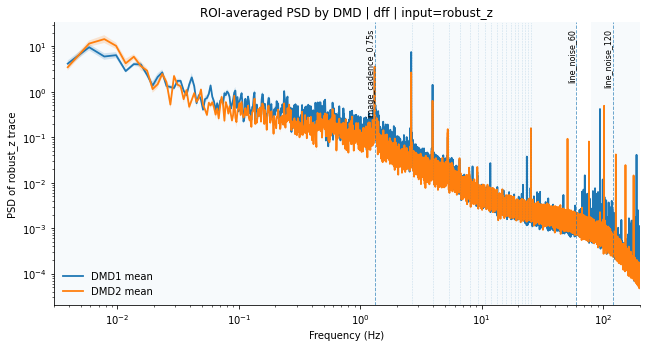

In [73]:
# %%
def _sem(x, axis=0):
    x = np.asarray(x)
    n = np.sum(np.isfinite(x), axis=axis)
    return np.nanstd(x, axis=axis, ddof=1) / np.sqrt(np.maximum(n, 1))


def _add_special_frequency_lines(ax, fmin, fmax, include_harmonics=True):
    """
    Add image cadence / line noise markers.
    """
    if "SPECIAL_FREQS" not in globals():
        special_freqs = {
            "image cadence": 1 / 0.75,
            "60 Hz": 60.0,
            "120 Hz": 120.0,
        }
    else:
        special_freqs = SPECIAL_FREQS

    for name, freq in special_freqs.items():
        if fmin <= freq <= fmax:
            ax.axvline(freq, linestyle="--", linewidth=0.9, alpha=0.7)
            ax.text(
                freq,
                0.98,
                name,
                transform=ax.get_xaxis_transform(),
                rotation=90,
                va="top",
                ha="right",
                fontsize=8,
            )

    if include_harmonics:
        image_freq = special_freqs.get("image_cadence_0.75s", 1 / 0.75)
        harmonics = image_freq * np.arange(2, 20)
        for freq in harmonics:
            if fmin <= freq <= fmax:
                ax.axvline(freq, linestyle=":", linewidth=0.6, alpha=0.35)


def _add_band_spans(ax, bands, fmin, fmax):
    """
    Add subtle spans for analysis bands.
    """
    for band, (lo, hi) in bands.items():
        lo2 = max(lo, fmin)
        hi2 = min(hi, fmax)
        if hi2 > lo2:
            ax.axvspan(lo2, hi2, alpha=0.035)


def plot_dmd_mean_psd(
    psd,
    fmin=0.003,
    fmax=200.0,
    show_bands=True,
    include_harmonics=True,
):
    fig, ax = plt.subplots(figsize=(10.5, 5.2))

    if show_bands and "FREQ_BANDS" in globals():
        _add_band_spans(ax, FREQ_BANDS, fmin=fmin, fmax=fmax)

    for dmd, d in psd["dmd"].items():
        f = d["f"]
        P = d["Pxx"]

        mask = (f >= fmin) & (f <= fmax)
        ff = f[mask]
        PP = P[:, mask]

        logP = np.log10(PP + PSD_EPS)

        mean_logP = np.nanmean(logP, axis=0)
        sem_logP = _sem(logP, axis=0)

        ax.plot(ff, 10 ** mean_logP, linewidth=1.8, label=f"{dmd} mean")
        ax.fill_between(
            ff,
            10 ** (mean_logP - sem_logP),
            10 ** (mean_logP + sem_logP),
            alpha=0.18,
            linewidth=0,
        )

    _add_special_frequency_lines(
        ax,
        fmin=fmin,
        fmax=fmax,
        include_harmonics=include_harmonics,
    )

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(fmin, fmax)

    ax.set_xlabel("Frequency (Hz)")
    if psd["input_mode"] == "raw":
        ax.set_ylabel("PSD")
    else:
        ax.set_ylabel(f"PSD of {psd['input_mode']} trace")

    ax.set_title(
        f"ROI-averaged PSD by DMD | {psd['signal']} | input={psd['input_mode']}"
    )
    ax.legend(frameon=False)
    ax.spines[["top", "right"]].set_visible(False)

    plt.show()


plot_dmd_mean_psd(
    psd,
    fmin=PSD_PLOT_FMIN,
    fmax=PSD_PLOT_FMAX,
    show_bands=True,
    include_harmonics=True,
)

### ROI-wise PSD heatmaps

#### These heatmaps show the spectral shape of each ROI.

#### For visualization, each ROI's log10 PSD is centered by subtracting that ROI's median log10 PSD.
#### This makes narrowband peaks and ROI-to-ROI spectral differences easier to see.

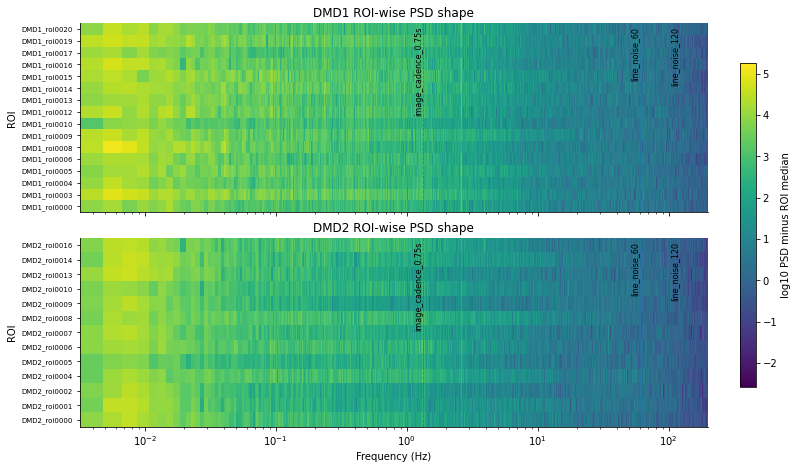

In [74]:
# %%
def _freq_edges_for_pcolormesh(f):
    """
    Frequency bin edges for log-scaled pcolormesh.
    """
    f = np.asarray(f, dtype=float)
    edges = np.empty(f.size + 1, dtype=float)

    edges[1:-1] = np.sqrt(f[:-1] * f[1:])
    edges[0] = f[0] ** 2 / edges[1]
    edges[-1] = f[-1] ** 2 / edges[-2]

    return edges


def plot_roi_psd_heatmaps(
    psd,
    fmin=0.003,
    fmax=200.0,
    row_center=True,
):
    dmd_keys = list(psd["dmd"].keys())
    n_dmds = len(dmd_keys)

    fig, axes = plt.subplots(
        n_dmds,
        1,
        figsize=(11, 3.2 * n_dmds),
        sharex=True,
        constrained_layout=True,
    )

    if n_dmds == 1:
        axes = [axes]

    meshes = []

    for ax, dmd in zip(axes, dmd_keys):
        d = psd["dmd"][dmd]
        f = d["f"]
        P = d["Pxx"]

        mask = (f >= fmin) & (f <= fmax)
        ff = f[mask]
        Z = np.log10(P[:, mask] + PSD_EPS)

        if row_center:
            Z = Z - np.nanmedian(Z, axis=1, keepdims=True)

        xedges = _freq_edges_for_pcolormesh(ff)
        yedges = np.arange(Z.shape[0] + 1)

        mesh = ax.pcolormesh(
            xedges,
            yedges,
            Z,
            shading="auto",
        )
        meshes.append(mesh)

        _add_special_frequency_lines(ax, fmin=fmin, fmax=fmax, include_harmonics=True)

        ax.set_xscale("log")
        ax.set_ylabel("ROI")
        ax.set_title(f"{dmd} ROI-wise PSD shape")

        ax.set_yticks(np.arange(Z.shape[0]) + 0.5)
        ax.set_yticklabels(d["roi_ids"], fontsize=7)

        ax.spines[["top", "right"]].set_visible(False)

    axes[-1].set_xlabel("Frequency (Hz)")

    cbar = fig.colorbar(meshes[-1], ax=axes, shrink=0.8)
    if row_center:
        cbar.set_label("log10 PSD minus ROI median")
    else:
        cbar.set_label("log10 PSD")

    plt.show()


plot_roi_psd_heatmaps(
    psd,
    fmin=PSD_PLOT_FMIN,
    fmax=PSD_PLOT_FMAX,
    row_center=True,
)

## Bandpower summaries

### For each ROI and frequency band, compute:

#### - absolute bandpower: integral of PSD across the band
#### - log10 bandpower
#### - fractional bandpower: bandpower divided by total power across `PSD_TOTAL_BAND`

### With `PSD_INPUT_MODE = "robust_z"`, absolute bandpower is in normalized units and is most useful for spectral shape.
### For absolute dF/F power, rerun with `PSD_INPUT_MODE = "raw"`.

In [75]:
# %%
# Define frequency bands for later summary analyses.
# These are intentionally broad and can be refined once we see the spectra.

FREQ_BANDS = {
    "ultra_slow_0.003_0.01": (0.003, 0.01),
    "slow_0.01_0.1": (0.01, 0.1),
    "state_0.1_0.5": (0.1, 0.5),
    "task_0.5_3": (0.5, 3.0),
    "low_fast_3_15": (3.0, 15.0),
    "mid_fast_15_60": (15.0, 60.0),
    "high_80_300": (80.0, 300.0),
}

SPECIAL_FREQS = {
    "image_cadence_0.75s": 1 / 0.75,
    "line_noise_60": 60.0,
    "line_noise_120": 120.0,
}

print("Frequency bands:")
display(pd.DataFrame([
    {"band": k, "low_hz": v[0], "high_hz": v[1]}
    for k, v in FREQ_BANDS.items()
]))

print("Special frequencies:")
display(pd.DataFrame([
    {"name": k, "freq_hz": v}
    for k, v in SPECIAL_FREQS.items()
]))

Frequency bands:


,band,low_hz,high_hz
0,ultra_slow_0.003_0.01,0.003,0.01
1,slow_0.01_0.1,0.010,0.10
2,state_0.1_0.5,0.100,0.50
3,task_0.5_3,0.500,3.00
4,low_fast_3_15,3.000,15.00
5,mid_fast_15_60,15.000,60.00
6,high_80_300,80.000,300.00


Special frequencies:


,name,freq_hz
0,image_cadence_0.75s,1.333333
1,line_noise_60,60.000000
2,line_noise_120,120.000000


In [76]:
# %%
def integrate_bandpower(f, Pxx, bands, total_band=(0.003, 200.0), eps=1e-20):
    """
    Integrate PSD over frequency bands.

    Parameters
    ----------
    f : ndarray
        Frequency vector.
    Pxx : ndarray
        ROI x frequency PSD.
    bands : dict
        band_name -> (low_hz, high_hz)
    total_band : tuple
        Frequency range used for fractional power denominator.

    Returns
    -------
    rows : list of dict
    """
    f = np.asarray(f, dtype=float)
    Pxx = np.asarray(Pxx, dtype=float)

    total_mask = (f >= total_band[0]) & (f <= total_band[1])
    if np.sum(total_mask) < 2:
        total_power = np.full(Pxx.shape[0], np.nan)
    else:
        total_power = np.trapz(Pxx[:, total_mask], f[total_mask], axis=1)

    rows = []

    for band, (lo, hi) in bands.items():
        mask = (f >= lo) & (f <= hi)

        if np.sum(mask) < 2:
            band_power = np.full(Pxx.shape[0], np.nan)
        else:
            band_power = np.trapz(Pxx[:, mask], f[mask], axis=1)

        frac = band_power / np.maximum(total_power, eps)

        for roi_idx in range(Pxx.shape[0]):
            rows.append({
                "band": band,
                "low_hz": lo,
                "high_hz": hi,
                "roi_index": roi_idx,
                "bandpower": band_power[roi_idx],
                "log10_bandpower": np.log10(band_power[roi_idx] + eps),
                "fractional_power": frac[roi_idx],
                "total_power": total_power[roi_idx],
            })

    return rows


def compute_bandpower_dataframe(psd, bands, total_band=(0.003, 200.0)):
    rows = []

    for dmd, d in psd["dmd"].items():
        band_rows = integrate_bandpower(
            f=d["f"],
            Pxx=d["Pxx"],
            bands=bands,
            total_band=total_band,
        )

        for r in band_rows:
            roi_idx = r["roi_index"]
            r["dmd"] = dmd
            r["roi_id"] = d["roi_ids"][roi_idx]
            r["input_mode"] = psd["input_mode"]
            r["signal"] = psd["signal"]
            rows.append(r)

    return pd.DataFrame(rows)


bandpower_df = compute_bandpower_dataframe(
    psd,
    bands=FREQ_BANDS,
    total_band=PSD_TOTAL_BAND,
)

display(bandpower_df.head())

,band,low_hz,high_hz,roi_index,bandpower,log10_bandpower,fractional_power,total_power,dmd,roi_id,input_mode,signal
0,ultra_slow_0.003_0.01,0.003,0.01,0,0.023500,-1.628927,0.024154,0.972925,DMD1,DMD1_roi0000,robust_z,dff
1,ultra_slow_0.003_0.01,0.003,0.01,1,0.060804,-1.216065,0.056749,1.071463,DMD1,DMD1_roi0003,robust_z,dff
2,ultra_slow_0.003_0.01,0.003,0.01,2,0.044309,-1.353506,0.046408,0.954771,DMD1,DMD1_roi0004,robust_z,dff
3,ultra_slow_0.003_0.01,0.003,0.01,3,0.025762,-1.589021,0.026393,0.976095,DMD1,DMD1_roi0005,robust_z,dff
4,ultra_slow_0.003_0.01,0.003,0.01,4,0.033262,-1.478047,0.036456,0.912403,DMD1,DMD1_roi0006,robust_z,dff


In [77]:
# %%
def summarize_bandpower_df(bandpower_df):
    summary = (
        bandpower_df
        .groupby(["band", "low_hz", "high_hz", "dmd"], observed=True)
        .agg(
            n_rois=("roi_id", "count"),
            mean_log10_bandpower=("log10_bandpower", "mean"),
            sem_log10_bandpower=("log10_bandpower", lambda x: np.nanstd(x, ddof=1) / np.sqrt(np.sum(np.isfinite(x)))),
            mean_fractional_power=("fractional_power", "mean"),
            sem_fractional_power=("fractional_power", lambda x: np.nanstd(x, ddof=1) / np.sqrt(np.sum(np.isfinite(x)))),
            mean_bandpower=("bandpower", "mean"),
            median_bandpower=("bandpower", "median"),
        )
        .reset_index()
        .sort_values(["low_hz", "dmd"])
    )

    return summary


bandpower_summary = summarize_bandpower_df(bandpower_df)
display(bandpower_summary)

,band,low_hz,high_hz,dmd,n_rois,mean_log10_bandpower,sem_log10_bandpower,mean_fractional_power,sem_fractional_power,mean_bandpower,median_bandpower
12,ultra_slow_0.003_0.01,0.003,0.01,DMD1,16,-1.370535,0.057960,0.045948,0.007998,0.049981,0.038712
13,ultra_slow_0.003_0.01,0.003,0.01,DMD2,13,-1.186602,0.073288,0.081371,0.012272,0.076010,0.083325
6,slow_0.01_0.1,0.010,0.10,DMD1,16,-0.940826,0.028925,0.110135,0.006796,0.118558,0.115867
7,slow_0.01_0.1,0.010,0.10,DMD2,13,-1.023477,0.040380,0.106027,0.009797,0.099807,0.101713
8,state_0.1_0.5,0.100,0.50,DMD1,16,-0.776565,0.024780,0.158684,0.006589,0.171407,0.163565
9,state_0.1_0.5,0.100,0.50,DMD2,13,-0.978911,0.040170,0.115688,0.009024,0.110668,0.098839
10,task_0.5_3,0.500,3.00,DMD1,16,-0.429818,0.020130,0.352207,0.013094,0.377542,0.367706
11,task_0.5_3,0.500,3.00,DMD2,13,-0.589063,0.059555,0.301913,0.037666,0.287744,0.273525
2,low_fast_3_15,3.000,15.00,DMD1,16,-0.818968,0.023557,0.144480,0.006761,0.155219,0.154971
3,low_fast_3_15,3.000,15.00,DMD2,13,-0.884574,0.035990,0.144805,0.012640,0.135973,0.123922


In [78]:
# %%
def compute_dmd_bandpower_contrasts(bandpower_summary):
    """
    Compute simple DMD2 - DMD1 contrasts in log10 bandpower and fractional power.
    This assumes DMD labels are DMD1 and DMD2.
    """
    if not {"DMD1", "DMD2"}.issubset(set(bandpower_summary["dmd"])):
        print("DMD1/DMD2 not both present; skipping contrast table.")
        return pd.DataFrame()

    wide_log = bandpower_summary.pivot(
        index=["band", "low_hz", "high_hz"],
        columns="dmd",
        values="mean_log10_bandpower",
    )

    wide_frac = bandpower_summary.pivot(
        index=["band", "low_hz", "high_hz"],
        columns="dmd",
        values="mean_fractional_power",
    )

    out = wide_log.reset_index()
    out["delta_log10_bandpower_DMD2_minus_DMD1"] = wide_log["DMD2"].values - wide_log["DMD1"].values
    out["fold_power_DMD2_over_DMD1"] = 10 ** out["delta_log10_bandpower_DMD2_minus_DMD1"]

    out["fractional_power_DMD1"] = wide_frac["DMD1"].values
    out["fractional_power_DMD2"] = wide_frac["DMD2"].values
    out["delta_fractional_power_DMD2_minus_DMD1"] = (
        wide_frac["DMD2"].values - wide_frac["DMD1"].values
    )

    out = out.sort_values("low_hz")
    return out


dmd_bandpower_contrasts = compute_dmd_bandpower_contrasts(bandpower_summary)
display(dmd_bandpower_contrasts)

dmd,band,low_hz,high_hz,DMD1,DMD2,delta_log10_bandpower_DMD2_minus_DMD1,fold_power_DMD2_over_DMD1,fractional_power_DMD1,fractional_power_DMD2,delta_fractional_power_DMD2_minus_DMD1
6,ultra_slow_0.003_0.01,0.003,0.01,-1.370535,-1.186602,0.183933,1.527329,0.045948,0.081371,0.035422
3,slow_0.01_0.1,0.010,0.10,-0.940826,-1.023477,-0.082651,0.826702,0.110135,0.106027,-0.004108
4,state_0.1_0.5,0.100,0.50,-0.776565,-0.978911,-0.202346,0.627558,0.158684,0.115688,-0.042996
5,task_0.5_3,0.500,3.00,-0.429818,-0.589063,-0.159245,0.693035,0.352207,0.301913,-0.050295
1,low_fast_3_15,3.000,15.00,-0.818968,-0.884574,-0.065606,0.859792,0.144480,0.144805,0.000325
2,mid_fast_15_60,15.000,60.00,-1.015209,-0.952744,0.062465,1.154690,0.092673,0.125125,0.032452
0,high_80_300,80.000,300.00,-1.213937,-1.205723,0.008215,1.019095,0.060615,0.072381,0.011766


## Plot bandpower by DMD

### First inspect fractional power because it asks:

#### > Of the activity in the analyzed spectrum, what fraction is assigned to each band?

### This is useful for seeing whether DMDs differ in spectral composition, independent of overall signal scale.

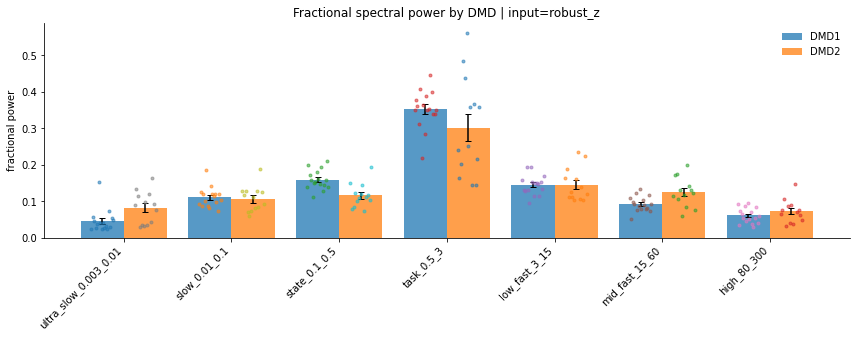

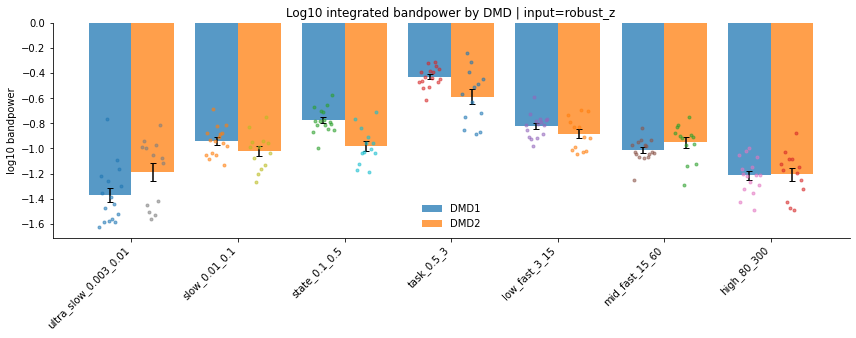

In [79]:
# %%
def plot_bandpower_summary(
    bandpower_df,
    value="fractional_power",
    title=None,
):
    bands_order = (
        bandpower_df[["band", "low_hz"]]
        .drop_duplicates()
        .sort_values("low_hz")["band"]
        .tolist()
    )
    dmds = sorted(bandpower_df["dmd"].unique())

    fig, ax = plt.subplots(figsize=(12, 4.8))

    x = np.arange(len(bands_order))
    width = 0.8 / max(1, len(dmds))

    for j, dmd in enumerate(dmds):
        means = []
        sems = []

        for band in bands_order:
            vals = bandpower_df.loc[
                (bandpower_df["dmd"] == dmd) &
                (bandpower_df["band"] == band),
                value,
            ].to_numpy(dtype=float)

            means.append(np.nanmean(vals))
            sems.append(np.nanstd(vals, ddof=1) / np.sqrt(np.sum(np.isfinite(vals))))

        xpos = x - 0.4 + width / 2 + j * width

        ax.bar(
            xpos,
            means,
            width=width,
            yerr=sems,
            capsize=3,
            alpha=0.75,
            label=dmd,
        )

        # ROI-level points
        for i, band in enumerate(bands_order):
            vals = bandpower_df.loc[
                (bandpower_df["dmd"] == dmd) &
                (bandpower_df["band"] == band),
                value,
            ].to_numpy(dtype=float)

            jitter = np.linspace(-0.25 * width, 0.25 * width, len(vals)) if len(vals) > 1 else np.array([0.0])
            ax.plot(
                np.full(len(vals), xpos[i]) + jitter,
                vals,
                marker="o",
                linestyle="none",
                markersize=3,
                alpha=0.55,
            )

    ax.set_xticks(x)
    ax.set_xticklabels(bands_order, rotation=45, ha="right")

    ax.set_ylabel(value.replace("_", " "))

    if title is None:
        title = f"Bandpower summary by DMD | value={value} | input={PSD_INPUT_MODE}"
    ax.set_title(title)

    ax.legend(frameon=False)
    ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    plt.show()


plot_bandpower_summary(
    bandpower_df,
    value="fractional_power",
    title=f"Fractional spectral power by DMD | input={PSD_INPUT_MODE}",
)

plot_bandpower_summary(
    bandpower_df,
    value="log10_bandpower",
    title=f"Log10 integrated bandpower by DMD | input={PSD_INPUT_MODE}",
)

## Optional: identify narrowband peaks in DMD-average PSD

### This is useful for flagging candidate stimulus/artifact frequencies.
### Peaks near 1.33 Hz and harmonics may reflect image cadence.
### Peaks near 60/120 Hz likely reflect line noise or electronics.

In [80]:
# %%
def find_mean_psd_peaks(
    psd,
    fmin=0.003,
    fmax=200.0,
    n_peaks=15,
    prominence=0.08,
    min_distance_hz=0.05,
    smooth_bins=9,
):
    rows = []

    for dmd, d in psd["dmd"].items():
        f = d["f"]
        P = d["Pxx"]

        mask = (f >= fmin) & (f <= fmax)
        ff = f[mask]

        logP = np.log10(np.nanmean(P[:, mask], axis=0) + PSD_EPS)

        if smooth_bins is not None and smooth_bins > 1:
            if smooth_bins % 2 == 0:
                smooth_bins += 1
            logP_smooth = scipy_signal.medfilt(logP, kernel_size=smooth_bins)
        else:
            logP_smooth = logP

        if len(ff) > 1:
            df = np.nanmedian(np.diff(ff))
            distance_bins = max(1, int(round(min_distance_hz / df)))
        else:
            distance_bins = 1

        peaks, props = scipy_signal.find_peaks(
            logP_smooth,
            prominence=prominence,
            distance=distance_bins,
        )

        if len(peaks) == 0:
            continue

        peak_rows = []
        for p, prom in zip(peaks, props["prominences"]):
            peak_rows.append({
                "dmd": dmd,
                "freq_hz": ff[p],
                "period_sec": 1 / ff[p],
                "mean_log10_psd": logP[p],
                "smoothed_log10_psd": logP_smooth[p],
                "prominence": prom,
            })

        peak_df = pd.DataFrame(peak_rows)
        peak_df = peak_df.sort_values("prominence", ascending=False).head(n_peaks)
        rows.append(peak_df)

    if len(rows) == 0:
        return pd.DataFrame()

    out = pd.concat(rows, ignore_index=True)
    out = out.sort_values(["dmd", "prominence"], ascending=[True, False])
    return out


psd_peak_table = find_mean_psd_peaks(
    psd,
    fmin=PSD_PLOT_FMIN,
    fmax=PSD_PLOT_FMAX,
    n_peaks=15,
    prominence=0.08,
    min_distance_hz=0.05,
    smooth_bins=9,
)

display(psd_peak_table)

,dmd,freq_hz,period_sec,mean_log10_psd,smoothed_log10_psd,prominence
0,DMD1,2.626957,0.380669,0.899196,-0.190762,1.193208
1,DMD1,3.941412,0.253716,0.200241,-0.483834,1.140196
2,DMD1,67.048924,0.014914,-2.086396,-2.086396,0.899195
3,DMD1,1.314455,0.760772,0.869438,-0.221400,0.743789
4,DMD1,5.253914,0.190334,-0.767935,-1.142502,0.628310
5,DMD1,9.197279,0.108728,-1.863677,-1.789091,0.456788
6,DMD1,134.105660,0.007457,-3.024927,-3.026750,0.444551
7,DMD1,94.154431,0.010621,0.203411,-2.741194,0.423233
8,DMD1,6.562509,0.152381,-1.555246,-1.548786,0.416445
9,DMD1,7.882824,0.126858,-1.552362,-1.700281,0.413560


## Analysis summnary so far:

The dominant frequency-domain structure in this session is a shared, image-cadence-locked component present on both DMDs and across many ROIs. There is no strong evidence here for DMD-specific slow-band subthreshold dynamics. The unexpected off-stimulus components in event averages may reflect stimulus-entrained population voltage dynamics and/or shared behavioral/state fluctuations rather than isolated change/omission responses. Narrow high-frequency peaks near line-noise ranges should be treated as artifacts unless validated in the time domain.

# Cross-DMD coherence and common/difference-mode analysis

## This section asks whether DMD1 and DMD2 contain shared frequency-domain structure.

## We compute:

### 1. DMD population traces:
####      - robust-z-score each ROI
####      - average across ROIs within each DMD

### 2. Cross-DMD coherence:
####      - frequency-specific coupling between DMD1 and DMD2 population traces

### 3. Common/difference decomposition:
####      - common = 0.5 * (DMD1 + DMD2)
####      - diff   = DMD1 - DMD2

### If the image-cadence component is shared, it should appear strongly in the common-mode PSD
### and weakly in the difference-mode PSD.

In [81]:
# %%
# ---------------------------------------------------------------------
# Cross-DMD analysis parameters
# ---------------------------------------------------------------------

COH_WINDOW_SEC = PSD_WINDOW_SEC
COH_OVERLAP_FRAC = PSD_OVERLAP_FRAC
COH_DETREND = "constant"

COMMON_DIFF_INPUT_MODE = "robust_z"
# This should usually match PSD_INPUT_MODE for first-pass analysis.

COH_FMIN = 0.003
COH_FMAX = 200.0

# For plotting coherence, values near 1 indicate strong shared frequency-specific structure.
COH_YLIM = (0, 1.02)

# Frequencies around special task/artifact values to summarize explicitly.
COH_SPECIAL_BAND_HALF_WIDTH_HZ = 0.05

In [82]:
# %%
def _get_population_trace_from_dmd(
    dmd_data,
    input_mode="robust_z",
    population_method="mean",
):
    """
    Convert ROI x time data from one DMD into one population trace.

    The default first robust-z-scores each ROI, then averages across ROIs.
    This emphasizes shared temporal structure rather than absolute amplitude.
    """
    X = dmd_data["X"]
    Xp = preprocess_X_for_psd(X, mode=input_mode)

    if population_method == "mean":
        y = np.nanmean(Xp, axis=0)
    elif population_method == "median":
        y = np.nanmedian(Xp, axis=0)
    else:
        raise ValueError(f"Unknown population_method: {population_method}")

    return np.asarray(y, dtype=np.float32)


def _align_two_dmd_population_traces(lf, dmd1="DMD1", dmd2="DMD2", input_mode="robust_z"):
    """
    Return aligned population traces for two DMDs.

    In most sessions, low-frequency timebases should be identical or nearly identical.
    If they are not, DMD2 is interpolated onto DMD1's timebase over the shared interval.
    """
    d1 = lf["dmd"][dmd1]
    d2 = lf["dmd"][dmd2]

    t1 = np.asarray(d1["time_sec"], dtype=np.float64)
    t2 = np.asarray(d2["time_sec"], dtype=np.float64)

    y1 = _get_population_trace_from_dmd(d1, input_mode=input_mode)
    y2 = _get_population_trace_from_dmd(d2, input_mode=input_mode)

    fs1 = float(d1["fs_low_hz"])
    fs2 = float(d2["fs_low_hz"])

    if abs(fs1 - fs2) > 1e-6:
        print(f"Warning: low-frequency fs differs: {dmd1}={fs1:.6f}, {dmd2}={fs2:.6f}")

    n_min = min(len(t1), len(t2))

    same_length = len(t1) == len(t2)
    same_time = same_length and np.allclose(t1, t2, rtol=0, atol=0.5 / fs1)

    if same_time:
        t = t1
        y1a = y1
        y2a = y2

        # Use DMD1 segment table.
        segments = _get_low_segments_as_int(d1["segments_low"], len(t))

    else:
        print("DMD timebases are not identical; interpolating DMD2 onto DMD1 over shared interval.")

        t_start = max(float(np.nanmin(t1)), float(np.nanmin(t2)))
        t_stop = min(float(np.nanmax(t1)), float(np.nanmax(t2)))

        keep = (t1 >= t_start) & (t1 <= t_stop)

        t = t1[keep]
        y1a = y1[keep]
        y2a = np.interp(t, t2, y2).astype(np.float32)

        # Conservative fallback: treat the shared interval as one segment.
        # If there are many imaging gaps, this can be made stricter later.
        segments = np.asarray([[0, len(t)]], dtype=np.int64)

    # Final cleanup
    y1a = _interp_nans_1d(y1a)
    y2a = _interp_nans_1d(y2a)

    return {
        "dmd1": dmd1,
        "dmd2": dmd2,
        "time_sec": t,
        "y1": y1a,
        "y2": y2a,
        "fs_hz": fs1,
        "segments": segments,
        "input_mode": input_mode,
    }


dmd_pair = _align_two_dmd_population_traces(
    lf,
    dmd1="DMD1",
    dmd2="DMD2",
    input_mode=COMMON_DIFF_INPUT_MODE,
)

print("Aligned DMD population traces")
print("  DMD1:", dmd_pair["dmd1"])
print("  DMD2:", dmd_pair["dmd2"])
print("  n samples:", len(dmd_pair["time_sec"]))
print("  fs:", dmd_pair["fs_hz"])
print("  duration min:", len(dmd_pair["time_sec"]) / dmd_pair["fs_hz"] / 60)
print("  n segments:", len(dmd_pair["segments"]))

Aligned DMD population traces
  DMD1: DMD1
  DMD2: DMD2
  n samples: 890737
  fs: 508.89135074062193
  duration min: 29.17246804265959
  n segments: 3


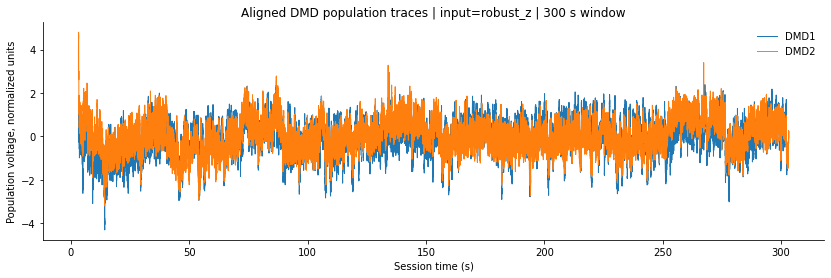

In [83]:
# %%
def plot_aligned_dmd_population_traces(dmd_pair, start_sec=None, duration_sec=300):
    """
    Quick sanity plot of the aligned DMD population traces.
    """
    t = dmd_pair["time_sec"]
    y1 = dmd_pair["y1"]
    y2 = dmd_pair["y2"]

    if start_sec is None:
        start_sec = float(t[0])

    stop_sec = start_sec + duration_sec
    idx = (t >= start_sec) & (t <= stop_sec)

    fig, ax = plt.subplots(figsize=(14, 4))

    ax.plot(t[idx], y1[idx], lw=1.0, label=dmd_pair["dmd1"])
    ax.plot(t[idx], y2[idx], lw=1.0, label=dmd_pair["dmd2"])

    ax.set_title(
        f"Aligned DMD population traces | input={dmd_pair['input_mode']} | "
        f"{duration_sec:g} s window"
    )
    ax.set_xlabel("Session time (s)")
    ax.set_ylabel("Population voltage, normalized units")
    ax.legend(frameon=False)
    ax.spines[["top", "right"]].set_visible(False)

    plt.show()


plot_aligned_dmd_population_traces(
    dmd_pair,
    start_sec=None,
    duration_sec=300,
)

## Cross-DMD coherence

## Coherence is a frequency-domain measure of shared structure between two signals.

### Values close to 1 mean that DMD1 and DMD2 share reliable phase/amplitude structure
### at that frequency.

### Values close to 0 mean that DMD1 and DMD2 are largely independent at that frequency.

In [84]:
# %%
def compute_segmented_cross_spectrum(
    x,
    y,
    fs_hz,
    segments=None,
    window_sec=512.0,
    overlap_frac=0.5,
    detrend="constant",
):
    """
    Compute segmented auto/cross spectra and coherence.

    This avoids spectral estimation across imaging/timebase gaps.
    """
    x = _interp_nans_1d(np.asarray(x, dtype=np.float32))
    y = _interp_nans_1d(np.asarray(y, dtype=np.float32))

    if len(x) != len(y):
        raise ValueError("x and y must have the same length.")

    n_time = len(x)
    fs_hz = float(fs_hz)

    if segments is None:
        segments = np.asarray([[0, n_time]], dtype=np.int64)
    else:
        segments = np.asarray(segments, dtype=np.int64)

    requested_nperseg = int(round(window_sec * fs_hz))
    requested_nperseg = max(8, requested_nperseg)

    seg_lengths = segments[:, 1] - segments[:, 0]
    usable = seg_lengths >= requested_nperseg

    if not np.any(usable):
        longest = int(np.max(seg_lengths))
        nperseg = max(8, longest)
        usable = seg_lengths >= nperseg
        print(
            f"No segment was long enough for requested coherence window "
            f"({requested_nperseg / fs_hz:.1f} s). "
            f"Using longest available segment window: {nperseg / fs_hz:.1f} s."
        )
    else:
        nperseg = requested_nperseg

    noverlap = int(round(overlap_frac * nperseg))
    noverlap = min(noverlap, nperseg - 1)
    step = nperseg - noverlap

    Sxx_accum = None
    Syy_accum = None
    Sxy_accum = None
    f_ref = None
    weight_accum = 0.0
    used_segments = []

    for start, stop in segments[usable]:
        start = int(start)
        stop = int(stop)
        n = stop - start

        if n < nperseg:
            continue

        xs = x[start:stop]
        ys = y[start:stop]

        f, Sxx = scipy_signal.welch(
            xs,
            fs=fs_hz,
            window="hann",
            nperseg=nperseg,
            noverlap=noverlap,
            detrend=detrend,
            return_onesided=True,
            scaling="density",
        )

        f2, Syy = scipy_signal.welch(
            ys,
            fs=fs_hz,
            window="hann",
            nperseg=nperseg,
            noverlap=noverlap,
            detrend=detrend,
            return_onesided=True,
            scaling="density",
        )

        f3, Sxy = scipy_signal.csd(
            xs,
            ys,
            fs=fs_hz,
            window="hann",
            nperseg=nperseg,
            noverlap=noverlap,
            detrend=detrend,
            return_onesided=True,
            scaling="density",
        )

        if not (np.allclose(f, f2) and np.allclose(f, f3)):
            raise RuntimeError("Frequency vectors differed across spectral estimates.")

        n_windows = 1 + max(0, (n - nperseg) // step)
        weight = float(n_windows)

        if Sxx_accum is None:
            Sxx_accum = weight * Sxx
            Syy_accum = weight * Syy
            Sxy_accum = weight * Sxy
            f_ref = f
        else:
            Sxx_accum += weight * Sxx
            Syy_accum += weight * Syy
            Sxy_accum += weight * Sxy

        weight_accum += weight
        used_segments.append((start, stop, n_windows))

    if Sxx_accum is None:
        raise RuntimeError("No usable segments for cross-spectrum computation.")

    Sxx = Sxx_accum / weight_accum
    Syy = Syy_accum / weight_accum
    Sxy = Sxy_accum / weight_accum

    coherence = (np.abs(Sxy) ** 2) / np.maximum(Sxx * Syy, PSD_EPS)
    phase_rad = np.angle(Sxy)

    meta = {
        "fs_hz": fs_hz,
        "requested_window_sec": float(window_sec),
        "actual_window_sec": float(nperseg / fs_hz),
        "freq_resolution_hz": float(f_ref[1] - f_ref[0]) if len(f_ref) > 1 else np.nan,
        "nperseg": int(nperseg),
        "noverlap": int(noverlap),
        "n_input_segments": int(len(segments)),
        "n_used_segments": int(len(used_segments)),
        "total_windows": int(weight_accum),
        "used_segments": used_segments,
    }

    return {
        "f": f_ref,
        "Sxx": Sxx,
        "Syy": Syy,
        "Sxy": Sxy,
        "coherence": coherence,
        "phase_rad": phase_rad,
        "meta": meta,
    }


cross = compute_segmented_cross_spectrum(
    x=dmd_pair["y1"],
    y=dmd_pair["y2"],
    fs_hz=dmd_pair["fs_hz"],
    segments=dmd_pair["segments"],
    window_sec=COH_WINDOW_SEC,
    overlap_frac=COH_OVERLAP_FRAC,
    detrend=COH_DETREND,
)

print("Cross-DMD coherence metadata")
for k, v in cross["meta"].items():
    if k != "used_segments":
        print(f"  {k}: {v}")

Cross-DMD coherence metadata
  fs_hz: 508.89135074062193
  requested_window_sec: 512.0
  actual_window_sec: 511.9992698260682
  freq_resolution_hz: 0.0019531277853964734
  nperseg: 260552
  noverlap: 130276
  n_input_segments: 3
  n_used_segments: 1
  total_windows: 4


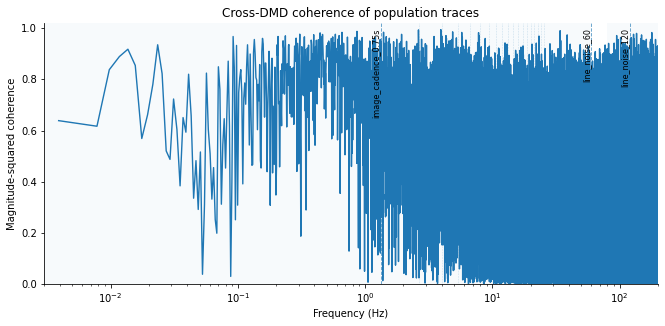

In [85]:
# %%
def plot_cross_dmd_coherence(
    cross,
    fmin=0.003,
    fmax=200.0,
    ylim=(0, 1.02),
    include_harmonics=True,
):
    f = cross["f"]
    coh = cross["coherence"]

    mask = (f >= fmin) & (f <= fmax)

    fig, ax = plt.subplots(figsize=(11, 4.8))

    if "FREQ_BANDS" in globals():
        _add_band_spans(ax, FREQ_BANDS, fmin=fmin, fmax=fmax)

    ax.plot(f[mask], coh[mask], lw=1.4)

    _add_special_frequency_lines(
        ax,
        fmin=fmin,
        fmax=fmax,
        include_harmonics=include_harmonics,
    )

    ax.set_xscale("log")
    ax.set_xlim(fmin, fmax)
    ax.set_ylim(*ylim)

    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("Magnitude-squared coherence")
    ax.set_title("Cross-DMD coherence of population traces")
    ax.spines[["top", "right"]].set_visible(False)

    plt.show()


plot_cross_dmd_coherence(
    cross,
    fmin=COH_FMIN,
    fmax=COH_FMAX,
    ylim=COH_YLIM,
    include_harmonics=True,
)

In [86]:
# %%
def summarize_coherence_by_band(cross, bands, special_freqs=None, special_half_width_hz=0.05):
    """
    Summarize coherence within broad bands and around special frequencies.
    """
    f = np.asarray(cross["f"], dtype=float)
    coh = np.asarray(cross["coherence"], dtype=float)

    rows = []

    for band, (lo, hi) in bands.items():
        mask = (f >= lo) & (f <= hi)

        if np.sum(mask) == 0:
            mean_coh = np.nan
            median_coh = np.nan
            max_coh = np.nan
            freq_at_max = np.nan
        else:
            mean_coh = float(np.nanmean(coh[mask]))
            median_coh = float(np.nanmedian(coh[mask]))
            max_idx = np.nanargmax(coh[mask])
            f_band = f[mask]
            c_band = coh[mask]
            max_coh = float(c_band[max_idx])
            freq_at_max = float(f_band[max_idx])

        rows.append({
            "type": "band",
            "name": band,
            "low_hz": lo,
            "high_hz": hi,
            "mean_coherence": mean_coh,
            "median_coherence": median_coh,
            "max_coherence": max_coh,
            "freq_at_max_hz": freq_at_max,
        })

    if special_freqs is None and "SPECIAL_FREQS" in globals():
        special_freqs = SPECIAL_FREQS

    if special_freqs is not None:
        for name, freq in special_freqs.items():
            lo = freq - special_half_width_hz
            hi = freq + special_half_width_hz
            mask = (f >= lo) & (f <= hi)

            if np.sum(mask) == 0:
                mean_coh = np.nan
                median_coh = np.nan
                max_coh = np.nan
                freq_at_max = np.nan
            else:
                mean_coh = float(np.nanmean(coh[mask]))
                median_coh = float(np.nanmedian(coh[mask]))
                max_idx = np.nanargmax(coh[mask])
                f_band = f[mask]
                c_band = coh[mask]
                max_coh = float(c_band[max_idx])
                freq_at_max = float(f_band[max_idx])

            rows.append({
                "type": "special",
                "name": name,
                "low_hz": lo,
                "high_hz": hi,
                "mean_coherence": mean_coh,
                "median_coherence": median_coh,
                "max_coherence": max_coh,
                "freq_at_max_hz": freq_at_max,
            })

    return pd.DataFrame(rows)


coherence_summary = summarize_coherence_by_band(
    cross,
    bands=FREQ_BANDS,
    special_freqs=SPECIAL_FREQS,
    special_half_width_hz=COH_SPECIAL_BAND_HALF_WIDTH_HZ,
)

display(coherence_summary)

,type,name,low_hz,high_hz,mean_coherence,median_coherence,max_coherence,freq_at_max_hz
0,band,ultra_slow_0.003_0.01,0.003000,0.010000,0.679689,0.632125,0.837737,0.009766
1,band,slow_0.01_0.1,0.010000,0.100000,0.575906,0.598646,0.967455,0.091797
2,band,state_0.1_0.5,0.100000,0.500000,0.784566,0.833928,0.981702,0.443360
3,band,task_0.5_3,0.500000,3.000000,0.638667,0.680164,0.993306,2.626957
4,band,low_fast_3_15,3.000000,15.000000,0.438453,0.434216,0.994153,3.939459
5,band,mid_fast_15_60,15.000000,60.000000,0.278166,0.236789,0.990218,34.105517
6,band,high_80_300,80.000000,300.000000,0.255914,0.213623,0.983067,179.127209
7,special,image_cadence_0.75s,1.283333,1.383333,0.594581,0.633540,0.955949,1.314455
8,special,line_noise_60,59.950000,60.050000,0.262639,0.284713,0.620337,60.000086
9,special,line_noise_120,119.950000,120.050000,0.244193,0.203535,0.743905,119.992359


## Common-mode vs difference-mode PSD

### Define:

####     common = 0.5 * (DMD1 + DMD2)
####     diff   = DMD1 - DMD2

## Interpretation:

### - Large common-mode power means the two DMDs share that frequency component.
### - Large difference-mode power means the DMDs differ at that frequency.
### - A low diff/common ratio at image cadence means the image-locked component is strongly shared.
### - A high diff/common ratio in a band could indicate DMD-specific biological signal or DMD-specific noise/artifact.

In [87]:
# %%
def compute_common_difference_traces(dmd_pair, zscore_pair=True):
    """
    Compute common and difference traces from aligned DMD population traces.

    Optionally z-score the two population traces before combining so that
    common/diff are not dominated by one DMD's amplitude scale.
    """
    y1 = np.asarray(dmd_pair["y1"], dtype=np.float32)
    y2 = np.asarray(dmd_pair["y2"], dtype=np.float32)

    if zscore_pair:
        y1 = preprocess_X_for_psd(y1[None, :], mode="zscore")[0]
        y2 = preprocess_X_for_psd(y2[None, :], mode="zscore")[0]

    common = 0.5 * (y1 + y2)
    diff = y1 - y2

    return {
        "time_sec": dmd_pair["time_sec"],
        "fs_hz": dmd_pair["fs_hz"],
        "segments": dmd_pair["segments"],
        "dmd1": y1,
        "dmd2": y2,
        "common": common.astype(np.float32),
        "diff": diff.astype(np.float32),
        "zscore_pair": zscore_pair,
    }


cd = compute_common_difference_traces(
    dmd_pair,
    zscore_pair=True,
)

In [88]:
# %%
def compute_single_trace_segmented_psd(
    y,
    fs_hz,
    segments=None,
    window_sec=512.0,
    overlap_frac=0.5,
    detrend="constant",
):
    """
    Compute segmented Welch PSD for one trace.
    """
    y = _interp_nans_1d(np.asarray(y, dtype=np.float32))
    fs_hz = float(fs_hz)

    if segments is None:
        segments = np.asarray([[0, len(y)]], dtype=np.int64)
    else:
        segments = np.asarray(segments, dtype=np.int64)

    requested_nperseg = int(round(window_sec * fs_hz))
    requested_nperseg = max(8, requested_nperseg)

    seg_lengths = segments[:, 1] - segments[:, 0]
    usable = seg_lengths >= requested_nperseg

    if not np.any(usable):
        longest = int(np.max(seg_lengths))
        nperseg = max(8, longest)
        usable = seg_lengths >= nperseg
        print(
            f"No segment was long enough for requested PSD window "
            f"({requested_nperseg / fs_hz:.1f} s). "
            f"Using longest available segment window: {nperseg / fs_hz:.1f} s."
        )
    else:
        nperseg = requested_nperseg

    noverlap = int(round(overlap_frac * nperseg))
    noverlap = min(noverlap, nperseg - 1)
    step = nperseg - noverlap

    P_accum = None
    f_ref = None
    weight_accum = 0.0
    used_segments = []

    for start, stop in segments[usable]:
        start = int(start)
        stop = int(stop)
        n = stop - start

        if n < nperseg:
            continue

        ys = y[start:stop]

        f, P = scipy_signal.welch(
            ys,
            fs=fs_hz,
            window="hann",
            nperseg=nperseg,
            noverlap=noverlap,
            detrend=detrend,
            return_onesided=True,
            scaling="density",
        )

        n_windows = 1 + max(0, (n - nperseg) // step)
        weight = float(n_windows)

        if P_accum is None:
            P_accum = weight * P
            f_ref = f
        else:
            if not np.allclose(f_ref, f):
                raise RuntimeError("Frequency vectors differed across segments.")
            P_accum += weight * P

        weight_accum += weight
        used_segments.append((start, stop, n_windows))

    if P_accum is None:
        raise RuntimeError("No usable segments for PSD computation.")

    Pxx = P_accum / weight_accum

    meta = {
        "fs_hz": fs_hz,
        "requested_window_sec": float(window_sec),
        "actual_window_sec": float(nperseg / fs_hz),
        "freq_resolution_hz": float(f_ref[1] - f_ref[0]) if len(f_ref) > 1 else np.nan,
        "nperseg": int(nperseg),
        "noverlap": int(noverlap),
        "n_input_segments": int(len(segments)),
        "n_used_segments": int(len(used_segments)),
        "total_windows": int(weight_accum),
        "used_segments": used_segments,
    }

    return f_ref, Pxx.astype(np.float32), meta


def compute_common_difference_psds(cd):
    out = {
        "fs_hz": cd["fs_hz"],
        "zscore_pair": cd["zscore_pair"],
        "traces": {},
    }

    for name in ["dmd1", "dmd2", "common", "diff"]:
        f, Pxx, meta = compute_single_trace_segmented_psd(
            y=cd[name],
            fs_hz=cd["fs_hz"],
            segments=cd["segments"],
            window_sec=PSD_WINDOW_SEC,
            overlap_frac=PSD_OVERLAP_FRAC,
            detrend=PSD_DETREND,
        )

        keep = (f >= PSD_TOTAL_BAND[0]) & (f <= min(PSD_TOTAL_BAND[1], cd["fs_hz"] / 2))

        out["traces"][name] = {
            "f": f[keep],
            "Pxx": Pxx[keep],
            "meta": meta,
        }

    return out


cd_psd = compute_common_difference_psds(cd)

print("Common/diff PSD metadata:")
for name, d in cd_psd["traces"].items():
    print()
    print(name)
    for k, v in d["meta"].items():
        if k != "used_segments":
            print(f"  {k}: {v}")

Common/diff PSD metadata:

dmd1
  fs_hz: 508.89135074062193
  requested_window_sec: 512.0
  actual_window_sec: 511.9992698260682
  freq_resolution_hz: 0.0019531277853964734
  nperseg: 260552
  noverlap: 130276
  n_input_segments: 3
  n_used_segments: 1
  total_windows: 4

dmd2
  fs_hz: 508.89135074062193
  requested_window_sec: 512.0
  actual_window_sec: 511.9992698260682
  freq_resolution_hz: 0.0019531277853964734
  nperseg: 260552
  noverlap: 130276
  n_input_segments: 3
  n_used_segments: 1
  total_windows: 4

common
  fs_hz: 508.89135074062193
  requested_window_sec: 512.0
  actual_window_sec: 511.9992698260682
  freq_resolution_hz: 0.0019531277853964734
  nperseg: 260552
  noverlap: 130276
  n_input_segments: 3
  n_used_segments: 1
  total_windows: 4

diff
  fs_hz: 508.89135074062193
  requested_window_sec: 512.0
  actual_window_sec: 511.9992698260682
  freq_resolution_hz: 0.0019531277853964734
  nperseg: 260552
  noverlap: 130276
  n_input_segments: 3
  n_used_segments: 1
  total

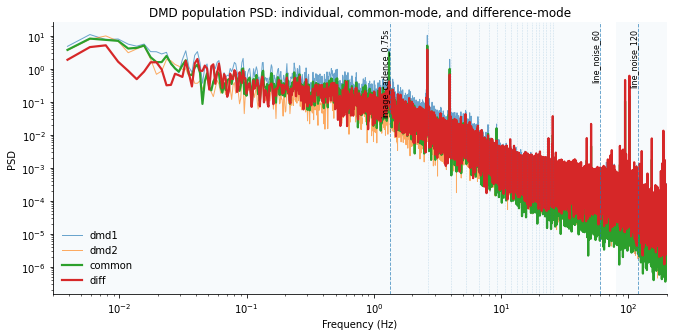

In [89]:
# %%
def plot_common_difference_psd(cd_psd, fmin=0.003, fmax=200.0):
    fig, ax = plt.subplots(figsize=(11, 5))

    if "FREQ_BANDS" in globals():
        _add_band_spans(ax, FREQ_BANDS, fmin=fmin, fmax=fmax)

    for name in ["dmd1", "dmd2", "common", "diff"]:
        d = cd_psd["traces"][name]
        f = d["f"]
        P = d["Pxx"]

        mask = (f >= fmin) & (f <= fmax)

        lw = 2.2 if name in ["common", "diff"] else 1.0
        alpha = 1.0 if name in ["common", "diff"] else 0.65

        ax.plot(f[mask], P[mask], lw=lw, alpha=alpha, label=name)

    _add_special_frequency_lines(
        ax,
        fmin=fmin,
        fmax=fmax,
        include_harmonics=True,
    )

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(fmin, fmax)

    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("PSD")
    ax.set_title("DMD population PSD: individual, common-mode, and difference-mode")
    ax.legend(frameon=False)
    ax.spines[["top", "right"]].set_visible(False)

    plt.show()


plot_common_difference_psd(
    cd_psd,
    fmin=PSD_PLOT_FMIN,
    fmax=PSD_PLOT_FMAX,
)

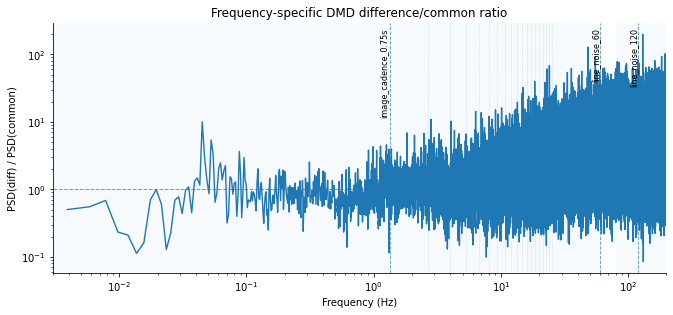

In [90]:
# %%
def plot_difference_over_common_ratio(cd_psd, fmin=0.003, fmax=200.0):
    f_common = cd_psd["traces"]["common"]["f"]
    P_common = cd_psd["traces"]["common"]["Pxx"]

    f_diff = cd_psd["traces"]["diff"]["f"]
    P_diff = cd_psd["traces"]["diff"]["Pxx"]

    if not np.allclose(f_common, f_diff):
        raise RuntimeError("Common and diff frequency axes do not match.")

    f = f_common
    ratio = P_diff / np.maximum(P_common, PSD_EPS)

    mask = (f >= fmin) & (f <= fmax)

    fig, ax = plt.subplots(figsize=(11, 4.6))

    if "FREQ_BANDS" in globals():
        _add_band_spans(ax, FREQ_BANDS, fmin=fmin, fmax=fmax)

    ax.plot(f[mask], ratio[mask], lw=1.4)
    ax.axhline(1.0, linestyle="--", linewidth=1.0, alpha=0.7)

    _add_special_frequency_lines(
        ax,
        fmin=fmin,
        fmax=fmax,
        include_harmonics=True,
    )

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(fmin, fmax)

    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("PSD(diff) / PSD(common)")
    ax.set_title("Frequency-specific DMD difference/common ratio")
    ax.spines[["top", "right"]].set_visible(False)

    plt.show()


plot_difference_over_common_ratio(
    cd_psd,
    fmin=PSD_PLOT_FMIN,
    fmax=PSD_PLOT_FMAX,
)

In [91]:
# %%
def summarize_common_difference_bandpower(cd_psd, bands, total_band=(0.003, 200.0)):
    rows = []

    for trace_name, d in cd_psd["traces"].items():
        f = d["f"]
        Pxx = d["Pxx"][None, :]

        band_rows = integrate_bandpower(
            f=f,
            Pxx=Pxx,
            bands=bands,
            total_band=total_band,
        )

        for r in band_rows:
            r["trace"] = trace_name
            rows.append(r)

    out = pd.DataFrame(rows)

    # Add diff/common ratio per band.
    wide = out.pivot(
        index=["band", "low_hz", "high_hz"],
        columns="trace",
        values="bandpower",
    ).reset_index()

    if {"common", "diff"}.issubset(wide.columns):
        wide["diff_over_common_bandpower"] = wide["diff"] / np.maximum(wide["common"], PSD_EPS)
        wide["log10_diff_over_common"] = np.log10(wide["diff_over_common_bandpower"] + PSD_EPS)

    wide = wide.sort_values("low_hz")

    return out, wide


cd_bandpower_long, cd_bandpower_summary = summarize_common_difference_bandpower(
    cd_psd,
    bands=FREQ_BANDS,
    total_band=PSD_TOTAL_BAND,
)

display(cd_bandpower_summary)

trace,band,low_hz,high_hz,common,diff,dmd1,dmd2,diff_over_common_bandpower,log10_diff_over_common
6,ultra_slow_0.003_0.01,0.003,0.01,0.041507,0.022505,0.049093,0.045174,0.542205,-0.265837
3,slow_0.01_0.1,0.010,0.10,0.084694,0.066629,0.139321,0.063381,0.786709,-0.104186
4,state_0.1_0.5,0.100,0.50,0.111028,0.092088,0.220860,0.047240,0.829413,-0.081229
5,task_0.5_3,0.500,3.00,0.198872,0.172086,0.389155,0.094632,0.865314,-0.062827
1,low_fast_3_15,3.000,15.00,0.046762,0.053526,0.090288,0.029999,1.144654,0.058674
2,mid_fast_15_60,15.000,60.00,0.007445,0.020571,0.015571,0.009603,2.763204,0.441413
0,high_80_300,80.000,300.00,0.003404,0.013634,0.008416,0.005208,4.005750,0.602684


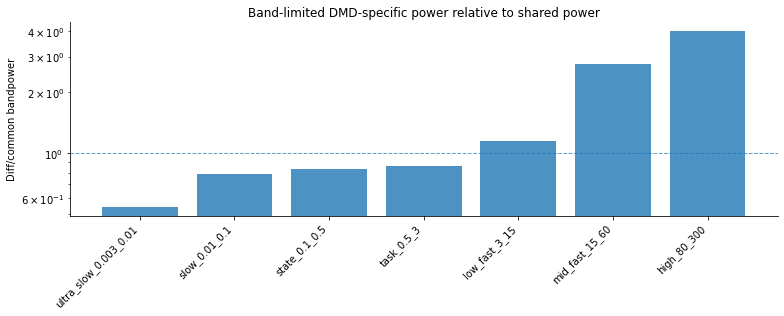

In [92]:
# %%
def plot_common_difference_bandpower_summary(cd_bandpower_summary):
    bands_order = (
        cd_bandpower_summary[["band", "low_hz"]]
        .drop_duplicates()
        .sort_values("low_hz")["band"]
        .tolist()
    )

    x = np.arange(len(bands_order))
    vals = []

    for band in bands_order:
        row = cd_bandpower_summary.loc[cd_bandpower_summary["band"] == band].iloc[0]
        vals.append(row["diff_over_common_bandpower"])

    fig, ax = plt.subplots(figsize=(11, 4.5))

    ax.bar(x, vals, alpha=0.8)
    ax.axhline(1.0, linestyle="--", linewidth=1.0, alpha=0.7)

    ax.set_yscale("log")
    ax.set_xticks(x)
    ax.set_xticklabels(bands_order, rotation=45, ha="right")

    ax.set_ylabel("Diff/common bandpower")
    ax.set_title("Band-limited DMD-specific power relative to shared power")
    ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    plt.show()


plot_common_difference_bandpower_summary(cd_bandpower_summary)

## Image-cadence harmonic check

### This summarizes coherence and diff/common ratio near the image cadence and its harmonics.

### If these rows show high coherence and low diff/common ratio, the image-related component is
### mostly shared across DMDs.

In [93]:
# %%
def summarize_harmonic_structure(
    cross,
    cd_psd,
    base_freq_hz=1 / 0.75,
    n_harmonics=12,
    half_width_hz=0.05,
):
    f_coh = np.asarray(cross["f"], dtype=float)
    coh = np.asarray(cross["coherence"], dtype=float)

    f_common = cd_psd["traces"]["common"]["f"]
    P_common = cd_psd["traces"]["common"]["Pxx"]
    f_diff = cd_psd["traces"]["diff"]["f"]
    P_diff = cd_psd["traces"]["diff"]["Pxx"]

    if not np.allclose(f_common, f_diff):
        raise RuntimeError("Common and diff frequency axes do not match.")

    ratio = P_diff / np.maximum(P_common, PSD_EPS)

    rows = []

    for h in range(1, n_harmonics + 1):
        target = h * base_freq_hz

        coh_mask = (f_coh >= target - half_width_hz) & (f_coh <= target + half_width_hz)
        ratio_mask = (f_common >= target - half_width_hz) & (f_common <= target + half_width_hz)

        if np.sum(coh_mask) > 0:
            local_coh = coh[coh_mask]
            local_f = f_coh[coh_mask]
            imax = np.nanargmax(local_coh)
            peak_coh = float(local_coh[imax])
            peak_coh_freq = float(local_f[imax])
            mean_coh = float(np.nanmean(local_coh))
        else:
            peak_coh = np.nan
            peak_coh_freq = np.nan
            mean_coh = np.nan

        if np.sum(ratio_mask) > 0:
            local_ratio = ratio[ratio_mask]
            local_f2 = f_common[ratio_mask]
            imin = np.nanargmin(local_ratio)
            min_ratio = float(local_ratio[imin])
            min_ratio_freq = float(local_f2[imin])
            median_ratio = float(np.nanmedian(local_ratio))
        else:
            min_ratio = np.nan
            min_ratio_freq = np.nan
            median_ratio = np.nan

        rows.append({
            "harmonic": h,
            "target_freq_hz": target,
            "target_period_sec": 1 / target,
            "mean_coherence": mean_coh,
            "peak_coherence": peak_coh,
            "peak_coherence_freq_hz": peak_coh_freq,
            "median_diff_over_common": median_ratio,
            "min_diff_over_common": min_ratio,
            "min_ratio_freq_hz": min_ratio_freq,
        })

    return pd.DataFrame(rows)


harmonic_summary = summarize_harmonic_structure(
    cross=cross,
    cd_psd=cd_psd,
    base_freq_hz=SPECIAL_FREQS.get("image_cadence_0.75s", 1 / 0.75),
    n_harmonics=12,
    half_width_hz=COH_SPECIAL_BAND_HALF_WIDTH_HZ,
)

display(harmonic_summary)

,harmonic,target_freq_hz,target_period_sec,mean_coherence,peak_coherence,peak_coherence_freq_hz,median_diff_over_common,min_diff_over_common,min_ratio_freq_hz
0,1,1.333333,0.750000,0.594581,0.955949,1.314455,1.081706,0.114861,1.312502
1,2,2.666667,0.375000,0.677132,0.993306,2.626957,0.962138,0.343492,2.619144
2,3,4.000000,0.250000,0.615555,0.969797,4.005865,1.069063,0.351103,3.972662
3,4,5.333333,0.187500,0.584134,0.926634,5.369148,1.347032,0.381108,5.359383
4,5,6.666667,0.150000,0.432977,0.867453,6.617197,1.586612,0.262574,6.617197
5,6,8.000000,0.125000,0.408183,0.858155,7.968761,1.359556,0.311367,7.982433
6,7,9.333333,0.107143,0.429585,0.889645,9.369154,1.371549,0.273709,9.371107
7,8,10.666667,0.093750,0.301838,0.832248,10.642593,2.067608,0.632162,10.642593
8,9,12.000000,0.083333,0.356634,0.808683,12.041033,1.599747,0.480391,11.955095
9,10,13.333333,0.075000,0.335390,0.852650,13.367207,2.039949,0.556096,13.367207


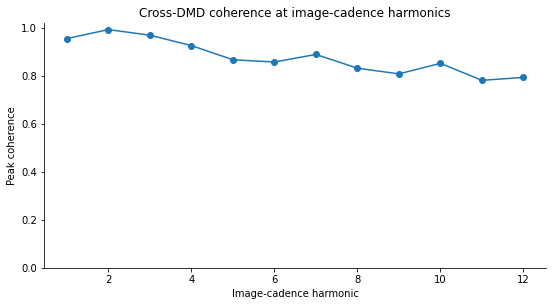

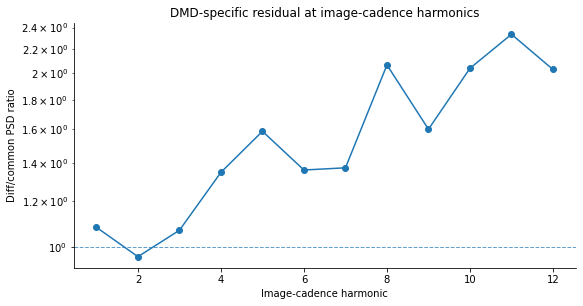

In [94]:
# %%
def plot_harmonic_summary(harmonic_summary):
    fig, ax = plt.subplots(figsize=(9, 4.5))

    ax.plot(
        harmonic_summary["harmonic"],
        harmonic_summary["peak_coherence"],
        marker="o",
        lw=1.5,
        label="Peak coherence",
    )

    ax.set_ylim(0, 1.02)
    ax.set_xlabel("Image-cadence harmonic")
    ax.set_ylabel("Peak coherence")
    ax.set_title("Cross-DMD coherence at image-cadence harmonics")
    ax.spines[["top", "right"]].set_visible(False)

    plt.show()

    fig, ax = plt.subplots(figsize=(9, 4.5))

    ax.plot(
        harmonic_summary["harmonic"],
        harmonic_summary["median_diff_over_common"],
        marker="o",
        lw=1.5,
        label="Median diff/common",
    )

    ax.axhline(1.0, linestyle="--", linewidth=1.0, alpha=0.7)
    ax.set_yscale("log")

    ax.set_xlabel("Image-cadence harmonic")
    ax.set_ylabel("Diff/common PSD ratio")
    ax.set_title("DMD-specific residual at image-cadence harmonics")
    ax.spines[["top", "right"]].set_visible(False)

    plt.show()


plot_harmonic_summary(harmonic_summary)


# ROI-pair coherence: within-DMD vs between-DMD

## The population-level common/difference analysis showed that DMD1 and DMD2 share
## slow/task-frequency structure, while diff/common power increases at higher frequencies.

## This section asks whether that high-frequency residual is coherent within DMDs.

### Pair classes:

#### - within_DMD1: all ROI pairs within DMD1
#### - within_DMD2: all ROI pairs within DMD2
#### - between_DMDs: all DMD1 x DMD2 ROI pairs

# Interpretation:

#### - If high-frequency coherence is higher within DMDs than between DMDs,
####  this supports DMD/depth-specific shared structure.
#### - If all high-frequency ROI-pair coherence is low, then the high-frequency
####   diff/common increase is more likely independent ROI noise or sparse local events.

In [95]:
# %%
# ---------------------------------------------------------------------
# ROI-pair coherence parameters
# ---------------------------------------------------------------------

PAIR_COH_INPUT_MODE = "demean"
PAIR_COH_WINDOW_SEC = 128.0
# Shorter than 512 s so we get more Welch windows and less fragile coherence estimates.
# Frequency resolution is ~0.008 Hz, still enough for task harmonics and broad bands.

PAIR_COH_OVERLAP_FRAC = 0.5
PAIR_COH_DETREND = "constant"

PAIR_COH_FMIN = 0.003
PAIR_COH_FMAX = 200.0

# To keep computation fast, set to None for all pairs.
# You can set e.g. 50 to randomly sample 50 between-DMD pairs.
PAIR_COH_MAX_PAIRS_PER_CLASS = None

PAIR_COH_RANDOM_SEED = 0

In [96]:
# %%
def _make_roi_pair_list(n1, n2=None, within=True):
    """
    Make ROI index pairs.

    If within=True:
        pairs are unique pairs within one set: i < j.
    If within=False:
        pairs are all cross pairs between set 1 and set 2.
    """
    pairs = []

    if within:
        for i in range(n1):
            for j in range(i + 1, n1):
                pairs.append((i, j))
    else:
        for i in range(n1):
            for j in range(n2):
                pairs.append((i, j))

    return pairs


def _subsample_pairs(pairs, max_pairs=None, random_seed=0):
    pairs = list(pairs)

    if max_pairs is None or len(pairs) <= max_pairs:
        return pairs

    rng = np.random.default_rng(random_seed)
    idx = rng.choice(len(pairs), size=max_pairs, replace=False)
    return [pairs[i] for i in idx]


def _compute_pair_coherence_matrix(
    X1,
    X2=None,
    fs_hz=None,
    segments=None,
    within=True,
    window_sec=128.0,
    overlap_frac=0.5,
    detrend="constant",
    input_mode="robust_z",
    max_pairs=None,
    random_seed=0,
):
    """
    Compute coherence for a set of ROI pairs.

    Returns
    -------
    f : ndarray
        Frequency vector.
    C : ndarray
        pair x frequency coherence matrix.
    pair_df : DataFrame
        Pair metadata.
    """
    X1p = preprocess_X_for_psd(X1, mode=input_mode)

    if within:
        X2p = X1p
        pairs = _make_roi_pair_list(X1p.shape[0], within=True)
    else:
        if X2 is None:
            raise ValueError("X2 is required for between-set coherence.")
        X2p = preprocess_X_for_psd(X2, mode=input_mode)
        pairs = _make_roi_pair_list(X1p.shape[0], X2p.shape[0], within=False)

    pairs = _subsample_pairs(
        pairs,
        max_pairs=max_pairs,
        random_seed=random_seed,
    )

    C_list = []
    pair_rows = []
    f_ref = None

    iterator = pairs
    if "tqdm" in globals() and tqdm is not None:
        iterator = tqdm(pairs, desc="ROI-pair coherence", total=len(pairs))

    for pair_idx, (i, j) in enumerate(iterator):
        x = X1p[i]
        y = X2p[j]

        out = compute_segmented_cross_spectrum(
            x=x,
            y=y,
            fs_hz=fs_hz,
            segments=segments,
            window_sec=window_sec,
            overlap_frac=overlap_frac,
            detrend=detrend,
        )

        f = out["f"]
        C = out["coherence"]

        if f_ref is None:
            f_ref = f
        else:
            if not np.allclose(f_ref, f):
                raise RuntimeError("Frequency axis changed across pairs.")

        C_list.append(C.astype(np.float32))

        pair_rows.append({
            "pair_index": pair_idx,
            "roi_i": i,
            "roi_j": j,
        })

    Cmat = np.vstack(C_list).astype(np.float32)
    pair_df = pd.DataFrame(pair_rows)

    return f_ref, Cmat, pair_df

In [97]:
# %%
def compute_roi_pair_coherence_by_class(
    lf,
    dmd1="DMD1",
    dmd2="DMD2",
    input_mode="robust_z",
    window_sec=128.0,
    overlap_frac=0.5,
    detrend="constant",
    max_pairs_per_class=None,
    random_seed=0,
):
    """
    Compute ROI-pair coherence for within-DMD and between-DMD pair classes.
    """
    d1 = lf["dmd"][dmd1]
    d2 = lf["dmd"][dmd2]

    # Assumes timebases are aligned as in the current session.
    # If not, this can be extended to interpolate onto a shared timebase.
    if d1["X"].shape[1] != d2["X"].shape[1]:
        raise ValueError("DMD arrays have different time lengths; align before pairwise coherence.")

    if not np.allclose(d1["time_sec"], d2["time_sec"], rtol=0, atol=0.5 / d1["fs_low_hz"]):
        raise ValueError("DMD timebases differ; align before pairwise coherence.")

    fs_hz = float(d1["fs_low_hz"])
    segments = _get_low_segments_as_int(d1["segments_low"], d1["X"].shape[1])

    out = {
        "input_mode": input_mode,
        "fs_hz": fs_hz,
        "window_sec": window_sec,
        "classes": {},
    }

    specs = [
        ("within_DMD1", d1["X"], None, True, d1["roi_ids"], None),
        ("within_DMD2", d2["X"], None, True, d2["roi_ids"], None),
        ("between_DMDs", d1["X"], d2["X"], False, d1["roi_ids"], d2["roi_ids"]),
    ]

    for class_name, X1, X2, within, roi_ids_1, roi_ids_2 in specs:
        print()
        print("=" * 80)
        print(f"Computing {class_name}")

        f, Cmat, pair_df = _compute_pair_coherence_matrix(
            X1=X1,
            X2=X2,
            fs_hz=fs_hz,
            segments=segments,
            within=within,
            window_sec=window_sec,
            overlap_frac=overlap_frac,
            detrend=detrend,
            input_mode=input_mode,
            max_pairs=max_pairs_per_class,
            random_seed=random_seed,
        )

        # Add ROI labels
        pair_df["roi_i_id"] = [roi_ids_1[i] for i in pair_df["roi_i"]]

        if within:
            pair_df["roi_j_id"] = [roi_ids_1[j] for j in pair_df["roi_j"]]
        else:
            pair_df["roi_j_id"] = [roi_ids_2[j] for j in pair_df["roi_j"]]

        out["classes"][class_name] = {
            "f": f,
            "coherence": Cmat,
            "pairs": pair_df,
        }

        print(f"n pairs: {Cmat.shape[0]}")
        print(f"n frequencies: {Cmat.shape[1]}")
        print(f"frequency resolution: {np.nanmedian(np.diff(f)):.5f} Hz")

    return out


pair_coh = compute_roi_pair_coherence_by_class(
    lf,
    dmd1="DMD1",
    dmd2="DMD2",
    input_mode=PAIR_COH_INPUT_MODE,
    window_sec=PAIR_COH_WINDOW_SEC,
    overlap_frac=PAIR_COH_OVERLAP_FRAC,
    detrend=PAIR_COH_DETREND,
    max_pairs_per_class=PAIR_COH_MAX_PAIRS_PER_CLASS,
    random_seed=PAIR_COH_RANDOM_SEED,
)


Computing within_DMD1


ROI-pair coherence:   0%|          | 0/120 [00:00<?, ?it/s]

n pairs: 120
n frequencies: 32570
frequency resolution: 0.00781 Hz

Computing within_DMD2


ROI-pair coherence:   0%|          | 0/78 [00:00<?, ?it/s]

n pairs: 78
n frequencies: 32570
frequency resolution: 0.00781 Hz

Computing between_DMDs


ROI-pair coherence:   0%|          | 0/208 [00:00<?, ?it/s]

n pairs: 208
n frequencies: 32570
frequency resolution: 0.00781 Hz


In [98]:
# %%
def summarize_pair_coherence_by_band(pair_coh, bands, fmin=None, fmax=None):
    rows = []

    for class_name, d in pair_coh["classes"].items():
        f = np.asarray(d["f"], dtype=float)
        C = np.asarray(d["coherence"], dtype=float)

        for band, (lo, hi) in bands.items():
            if fmin is not None:
                lo = max(lo, fmin)
            if fmax is not None:
                hi = min(hi, fmax)

            mask = (f >= lo) & (f <= hi)

            if np.sum(mask) == 0:
                vals = np.full(C.shape[0], np.nan)
            else:
                vals = np.nanmean(C[:, mask], axis=1)

            for pair_idx, val in enumerate(vals):
                rows.append({
                    "class": class_name,
                    "band": band,
                    "low_hz": lo,
                    "high_hz": hi,
                    "pair_index": pair_idx,
                    "mean_coherence": val,
                })

    return pd.DataFrame(rows)


pair_coh_band_df = summarize_pair_coherence_by_band(
    pair_coh,
    bands=FREQ_BANDS,
    fmin=PAIR_COH_FMIN,
    fmax=PAIR_COH_FMAX,
)

pair_coh_band_summary = (
    pair_coh_band_df
    .groupby(["class", "band", "low_hz", "high_hz"], observed=True)
    .agg(
        n_pairs=("pair_index", "count"),
        mean_coherence=("mean_coherence", "mean"),
        median_coherence=("mean_coherence", "median"),
        sem_coherence=("mean_coherence", lambda x: np.nanstd(x, ddof=1) / np.sqrt(np.sum(np.isfinite(x)))),
    )
    .reset_index()
    .sort_values(["low_hz", "class"])
)

display(pair_coh_band_summary)

,class,band,low_hz,high_hz,n_pairs,mean_coherence,median_coherence,sem_coherence
6,between_DMDs,ultra_slow_0.003_0.01,0.003,0.01,208,0.467262,0.458081,0.011433
13,within_DMD1,ultra_slow_0.003_0.01,0.003,0.01,120,0.563111,0.571049,0.013322
20,within_DMD2,ultra_slow_0.003_0.01,0.003,0.01,78,0.745468,0.750808,0.010231
3,between_DMDs,slow_0.01_0.1,0.010,0.10,208,0.297685,0.272654,0.008731
10,within_DMD1,slow_0.01_0.1,0.010,0.10,120,0.406411,0.408120,0.017764
17,within_DMD2,slow_0.01_0.1,0.010,0.10,78,0.603674,0.645497,0.019663
4,between_DMDs,state_0.1_0.5,0.100,0.50,208,0.410537,0.431762,0.010794
11,within_DMD1,state_0.1_0.5,0.100,0.50,120,0.564703,0.614102,0.015312
18,within_DMD2,state_0.1_0.5,0.100,0.50,78,0.433020,0.451148,0.023489
5,between_DMDs,task_0.5_3,0.500,3.00,208,0.239970,0.230745,0.007118


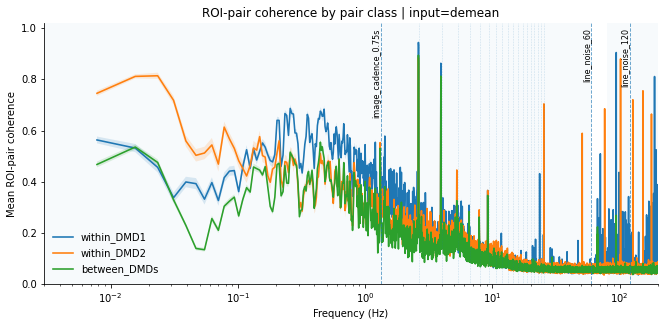

In [99]:
# %%
def plot_pair_coherence_spectra(
    pair_coh,
    fmin=0.003,
    fmax=200.0,
):
    fig, ax = plt.subplots(figsize=(11, 4.8))

    if "FREQ_BANDS" in globals():
        _add_band_spans(ax, FREQ_BANDS, fmin=fmin, fmax=fmax)

    for class_name, d in pair_coh["classes"].items():
        f = d["f"]
        C = d["coherence"]

        mask = (f >= fmin) & (f <= fmax)

        mean_C = np.nanmean(C[:, mask], axis=0)
        sem_C = _sem(C[:, mask], axis=0)

        ax.plot(f[mask], mean_C, lw=1.6, label=class_name)
        ax.fill_between(
            f[mask],
            mean_C - sem_C,
            mean_C + sem_C,
            alpha=0.15,
            linewidth=0,
        )

    _add_special_frequency_lines(
        ax,
        fmin=fmin,
        fmax=fmax,
        include_harmonics=True,
    )

    ax.set_xscale("log")
    ax.set_xlim(fmin, fmax)
    ax.set_ylim(0, 1.02)

    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("Mean ROI-pair coherence")
    ax.set_title(f"ROI-pair coherence by pair class | input={pair_coh['input_mode']}")
    ax.legend(frameon=False)
    ax.spines[["top", "right"]].set_visible(False)

    plt.show()


plot_pair_coherence_spectra(
    pair_coh,
    fmin=PAIR_COH_FMIN,
    fmax=PAIR_COH_FMAX,
)

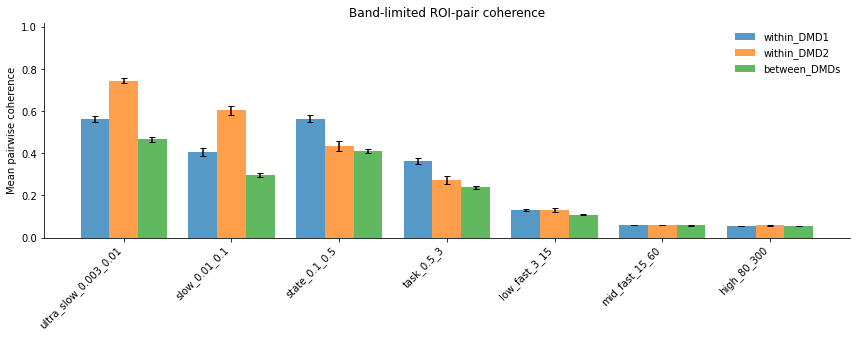

In [100]:
# %%
def plot_pair_coherence_band_summary(pair_coh_band_df):
    bands_order = (
        pair_coh_band_df[["band", "low_hz"]]
        .drop_duplicates()
        .sort_values("low_hz")["band"]
        .tolist()
    )

    classes = ["within_DMD1", "within_DMD2", "between_DMDs"]
    classes = [c for c in classes if c in set(pair_coh_band_df["class"])]

    x = np.arange(len(bands_order))
    width = 0.8 / len(classes)

    fig, ax = plt.subplots(figsize=(12, 4.8))

    for j, class_name in enumerate(classes):
        means = []
        sems = []

        for band in bands_order:
            vals = pair_coh_band_df.loc[
                (pair_coh_band_df["class"] == class_name) &
                (pair_coh_band_df["band"] == band),
                "mean_coherence",
            ].to_numpy(dtype=float)

            means.append(np.nanmean(vals))
            sems.append(np.nanstd(vals, ddof=1) / np.sqrt(np.sum(np.isfinite(vals))))

        xpos = x - 0.4 + width / 2 + j * width

        ax.bar(
            xpos,
            means,
            width=width,
            yerr=sems,
            capsize=3,
            alpha=0.75,
            label=class_name,
        )

    ax.set_xticks(x)
    ax.set_xticklabels(bands_order, rotation=45, ha="right")
    ax.set_ylim(0, 1.02)

    ax.set_ylabel("Mean pairwise coherence")
    ax.set_title("Band-limited ROI-pair coherence")
    ax.legend(frameon=False)
    ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    plt.show()


plot_pair_coherence_band_summary(pair_coh_band_df)

In [101]:
# %%
def compute_within_minus_between_contrast(pair_coh_band_summary):
    """
    Summarize whether within-DMD coherence exceeds between-DMD coherence.
    """
    rows = []

    for band in pair_coh_band_summary["band"].unique():
        sub = pair_coh_band_summary[pair_coh_band_summary["band"] == band]

        vals = {
            row["class"]: row["mean_coherence"]
            for _, row in sub.iterrows()
        }

        if "between_DMDs" not in vals:
            continue

        within_vals = [
            vals[c] for c in ["within_DMD1", "within_DMD2"]
            if c in vals
        ]

        if len(within_vals) == 0:
            continue

        within_mean = float(np.nanmean(within_vals))
        between = float(vals["between_DMDs"])

        band_info = sub.iloc[0]

        rows.append({
            "band": band,
            "low_hz": band_info["low_hz"],
            "high_hz": band_info["high_hz"],
            "within_mean_coherence": within_mean,
            "between_mean_coherence": between,
            "within_minus_between": within_mean - between,
            "within_over_between": within_mean / np.maximum(between, 1e-12),
        })

    return pd.DataFrame(rows).sort_values("low_hz")


pair_coh_contrast = compute_within_minus_between_contrast(pair_coh_band_summary)
display(pair_coh_contrast)

,band,low_hz,high_hz,within_mean_coherence,between_mean_coherence,within_minus_between,within_over_between
0,ultra_slow_0.003_0.01,0.003,0.01,0.654289,0.467262,0.187027,1.400262
1,slow_0.01_0.1,0.010,0.10,0.505043,0.297685,0.207357,1.696566
2,state_0.1_0.5,0.100,0.50,0.498861,0.410537,0.088324,1.215144
3,task_0.5_3,0.500,3.00,0.319651,0.239970,0.079681,1.332043
4,low_fast_3_15,3.000,15.00,0.130905,0.109425,0.021479,1.196293
5,mid_fast_15_60,15.000,60.00,0.060429,0.057623,0.002806,1.048698
6,high_80_300,80.000,200.00,0.057052,0.055094,0.001958,1.035544


In [102]:
asset

SessionAssets(session_id='826032_2026-02-10_13-02-11', subject_id=826032, session_dir=WindowsPath('//allen/aind/scratch/ophys/Andrew/VIP_synaptic_dynamics/ASAP7/826032/826032_2026-02-10_13-02-11'), summary_mat=None, bonsai_event_log_csv=WindowsPath('//allen/aind/scratch/ophys/Andrew/VIP_synaptic_dynamics/ASAP7/826032/826032_2026-02-10_13-02-11/826032_2026-02-10_13-02-11/behavior/VCO1_Behavior.harp/bonsai_event_log.csv'), harp_dir=WindowsPath('//allen/aind/scratch/ophys/Andrew/VIP_synaptic_dynamics/ASAP7/826032/826032_2026-02-10_13-02-11/826032_2026-02-10_13-02-11/behavior/VCO1_Behavior.harp'), photodiode_pkl=WindowsPath('//allen/aind/scratch/ophys/Andrew/VIP_synaptic_dynamics/ASAP7/826032/826032_2026-02-10_13-02-11/826032_2026-02-10_13-02-11/behavior/VCO1_Behavior.harp/extracted_files/photodiode.pkl'), harp_df_csv=WindowsPath('//allen/aind/scratch/ophys/Andrew/VIP_synaptic_dynamics/ASAP7/826032/826032_2026-02-10_13-02-11/826032_2026-02-10_13-02-11/behavior/VCO1_Behavior.harp/extracted_